# Core/comms PCA geometry smoketest

Short run (few participants, few epochs) to verify that:
1. Two-module RNN simulation runs and saves `hiddens_post_phase_*_core_per_module` and `..._comms_per_module` when the schedule has been extended.
2. Loaded data can be used for per-phase PCA geometry (combined, core-only, comms-only per module) and plotted in grouped figures.

Uses 3 participants per similarity (`geom_sub_same_1..3`, `geom_sub_near_1..3`, `geom_sub_far_1..3`) so that `load_ann_data` fills same/near/far with three runs each. If core/comms keys are missing (e.g. older schedule.py), the plotting section skips or warns.

## 1. Setup and imports

In [1]:
import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.training.simulation import run_simulation
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.transfer_interference import prepare_pca_single_task, setup_task_parameters
from a1b2.utils.figure_settings import task_colours
from a1b2.utils.figure_utils import plot_split_stim, get_axis_limits

data_folder = project_root / "data"
config_path = project_root / "a1b2" / "models" / "experiments.json"
with open(config_path, "r") as f:
    settings = json.load(f)

print("Project root:", project_root)
print("Data folder:", data_folder)

/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Data folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data


## 2. Pick condition and small training params

In [2]:
def pick_condition(settings, arch="two_module_rnn", dim_hidden=25, nb_steps=2):
    for c in settings["conditions"]:
        if c.get("arch") == arch and c.get("dim_hidden") == dim_hidden and c.get("nb_steps", 1) == nb_steps:
            return c
    raise RuntimeError("No matching condition found")

condition = pick_condition(settings)
task_parameters = ann.setup_task_parameters()

dim_input = task_parameters["nStim_perTask"] * 2
n_modules = condition.get("n_modules", 2)
hidden_size = condition.get("dim_hidden", 25)
dim_hidden = n_modules * hidden_size
dim_output = 4

n_phase = 3
n_epochs = 2
n_train_trials = n_epochs * dim_input * 2
shuffle = True
batch_size = 16
gamma = condition.get("gamma", 0.0) or 0.0
lr = settings.get("learning_rate", 1e-2)

training_params = [None, n_phase, n_epochs, n_train_trials, shuffle, batch_size, gamma, lr]
network_params = [dim_input, dim_hidden, dim_output]

test_sim_folder = data_folder / "simulations" / "core_comms_smoketest"
test_sim_folder.mkdir(parents=True, exist_ok=True)

print("Condition:", condition.get("name", "unnamed"))
print("Test sim folder:", test_sim_folder)

Condition: two_module_rnn_25_nb2
Test sim folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/core_comms_smoketest


## 3. Build geometry df and run short simulation

In [3]:
df = ann.load_participant_data(str(data_folder))
participant_to_copy = df["participant"].iloc[0]
geometry_df_base = ann.generate_geometry_df(df, participant_to_copy, near_rule=np.pi / 6, far_rule=np.pi)
# 3 participants per similarity (same, near, far)
n_per_similarity = 3
geometry_dfs = []
for base in ["geom_sub_same", "geom_sub_near", "geom_sub_far"]:
    sub = geometry_df_base[geometry_df_base["participant"] == base]
    for i in range(1, n_per_similarity + 1):
        c = sub.copy()
        c["participant"] = f"{base}_{i}"
        geometry_dfs.append(c)
geometry_df = pd.concat(geometry_dfs, ignore_index=True)
participants = (
    [f"geom_sub_same_{i}" for i in range(1, n_per_similarity + 1)]
    + [f"geom_sub_near_{i}" for i in range(1, n_per_similarity + 1)]
    + [f"geom_sub_far_{i}" for i in range(1, n_per_similarity + 1)]
)
training_params[0] = participants

results = run_simulation(
    training_params=training_params,
    network_params=network_params,
    task_parameters=task_parameters,
    df=geometry_df,
    do_test=0,
    dosave=1,
    sim_folder=str(test_sim_folder),
    arch="two_module_rnn",
    condition=condition,
)

print("Participants simulated:", [r["participant"] for r in results])
print("Sim files:", sorted(test_sim_folder.glob("*.npz")))

Participants:   0%|          | 0/3 [00:00<?, ?it/s]

Participants: 100%|██████████| 3/3 [00:05<00:00,  1.84s/it]

Participants simulated: ['geom_sub_same', 'geom_sub_near', 'geom_sub_far']
Sim files: [PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/core_comms_smoketest/sim_geom_sub_far.npz'), PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/core_comms_smoketest/sim_geom_sub_near.npz'), PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/core_comms_smoketest/sim_geom_sub_same.npz')]


## 4. Load ANN data (with core/comms if present)

In [4]:
ann_data = ann.load_ann_data(str(test_sim_folder), load_rnn_extra=True)

for sched_name, sched_data in ann_data.items():
    print(sched_name, "N participants:", len(sched_data))
    if len(sched_data) > 0:
        keys = sorted(sched_data[0].keys())
        print("Keys (sample):", keys[:5], "...")
        core_keys = [k for k in keys if "core_per_module" in k]
        comms_keys = [k for k in keys if "comms_per_module" in k]
        print("Core keys:", core_keys)
        print("Comms keys:", comms_keys)
        break

same N participants: 1
Keys (sample): ['accuracy', 'hiddens_per_module', 'hiddens_post_phase_0', 'hiddens_post_phase_0_comms_per_module', 'hiddens_post_phase_0_core_per_module'] ...
Core keys: ['hiddens_post_phase_0_core_per_module', 'hiddens_post_phase_1_core_per_module', 'hiddens_post_phase_2_core_per_module']
Comms keys: ['hiddens_post_phase_0_comms_per_module', 'hiddens_post_phase_1_comms_per_module', 'hiddens_post_phase_2_comms_per_module']


## 5. Helpers and per-phase core/comms PCA figures

In [5]:
schedules = ["same", "near", "far"]
schedule_to_idx = {"same": 0, "near": 1, "far": 2}

def get_hiddens_12_per_module(h_per, sched_name):
    if h_per is None or not hasattr(h_per, "shape"):
        return None
    if h_per.ndim == 4 and h_per.shape[0] == 3 and h_per.shape[1] >= 12:
        return h_per[schedule_to_idx[sched_name], :12, :, :].copy()
    if h_per.ndim == 3 and h_per.shape[0] >= 12 and h_per.shape[1] == 2:
        return h_per[:12, :, :].copy()
    return None

def pca_2d(X):
    if X is None:
        return None
    _, X2 = prepare_pca_single_task(X)
    return X2

def plot_geom(ax, X2, title, task_colours, lims):
    if X2 is None:
        ax.set_title(f"{title}\n(no data)")
        ax.axis("off")
        return
    plot_split_stim(ax, X2, task_colours, lims)
    ax.set_title(title)

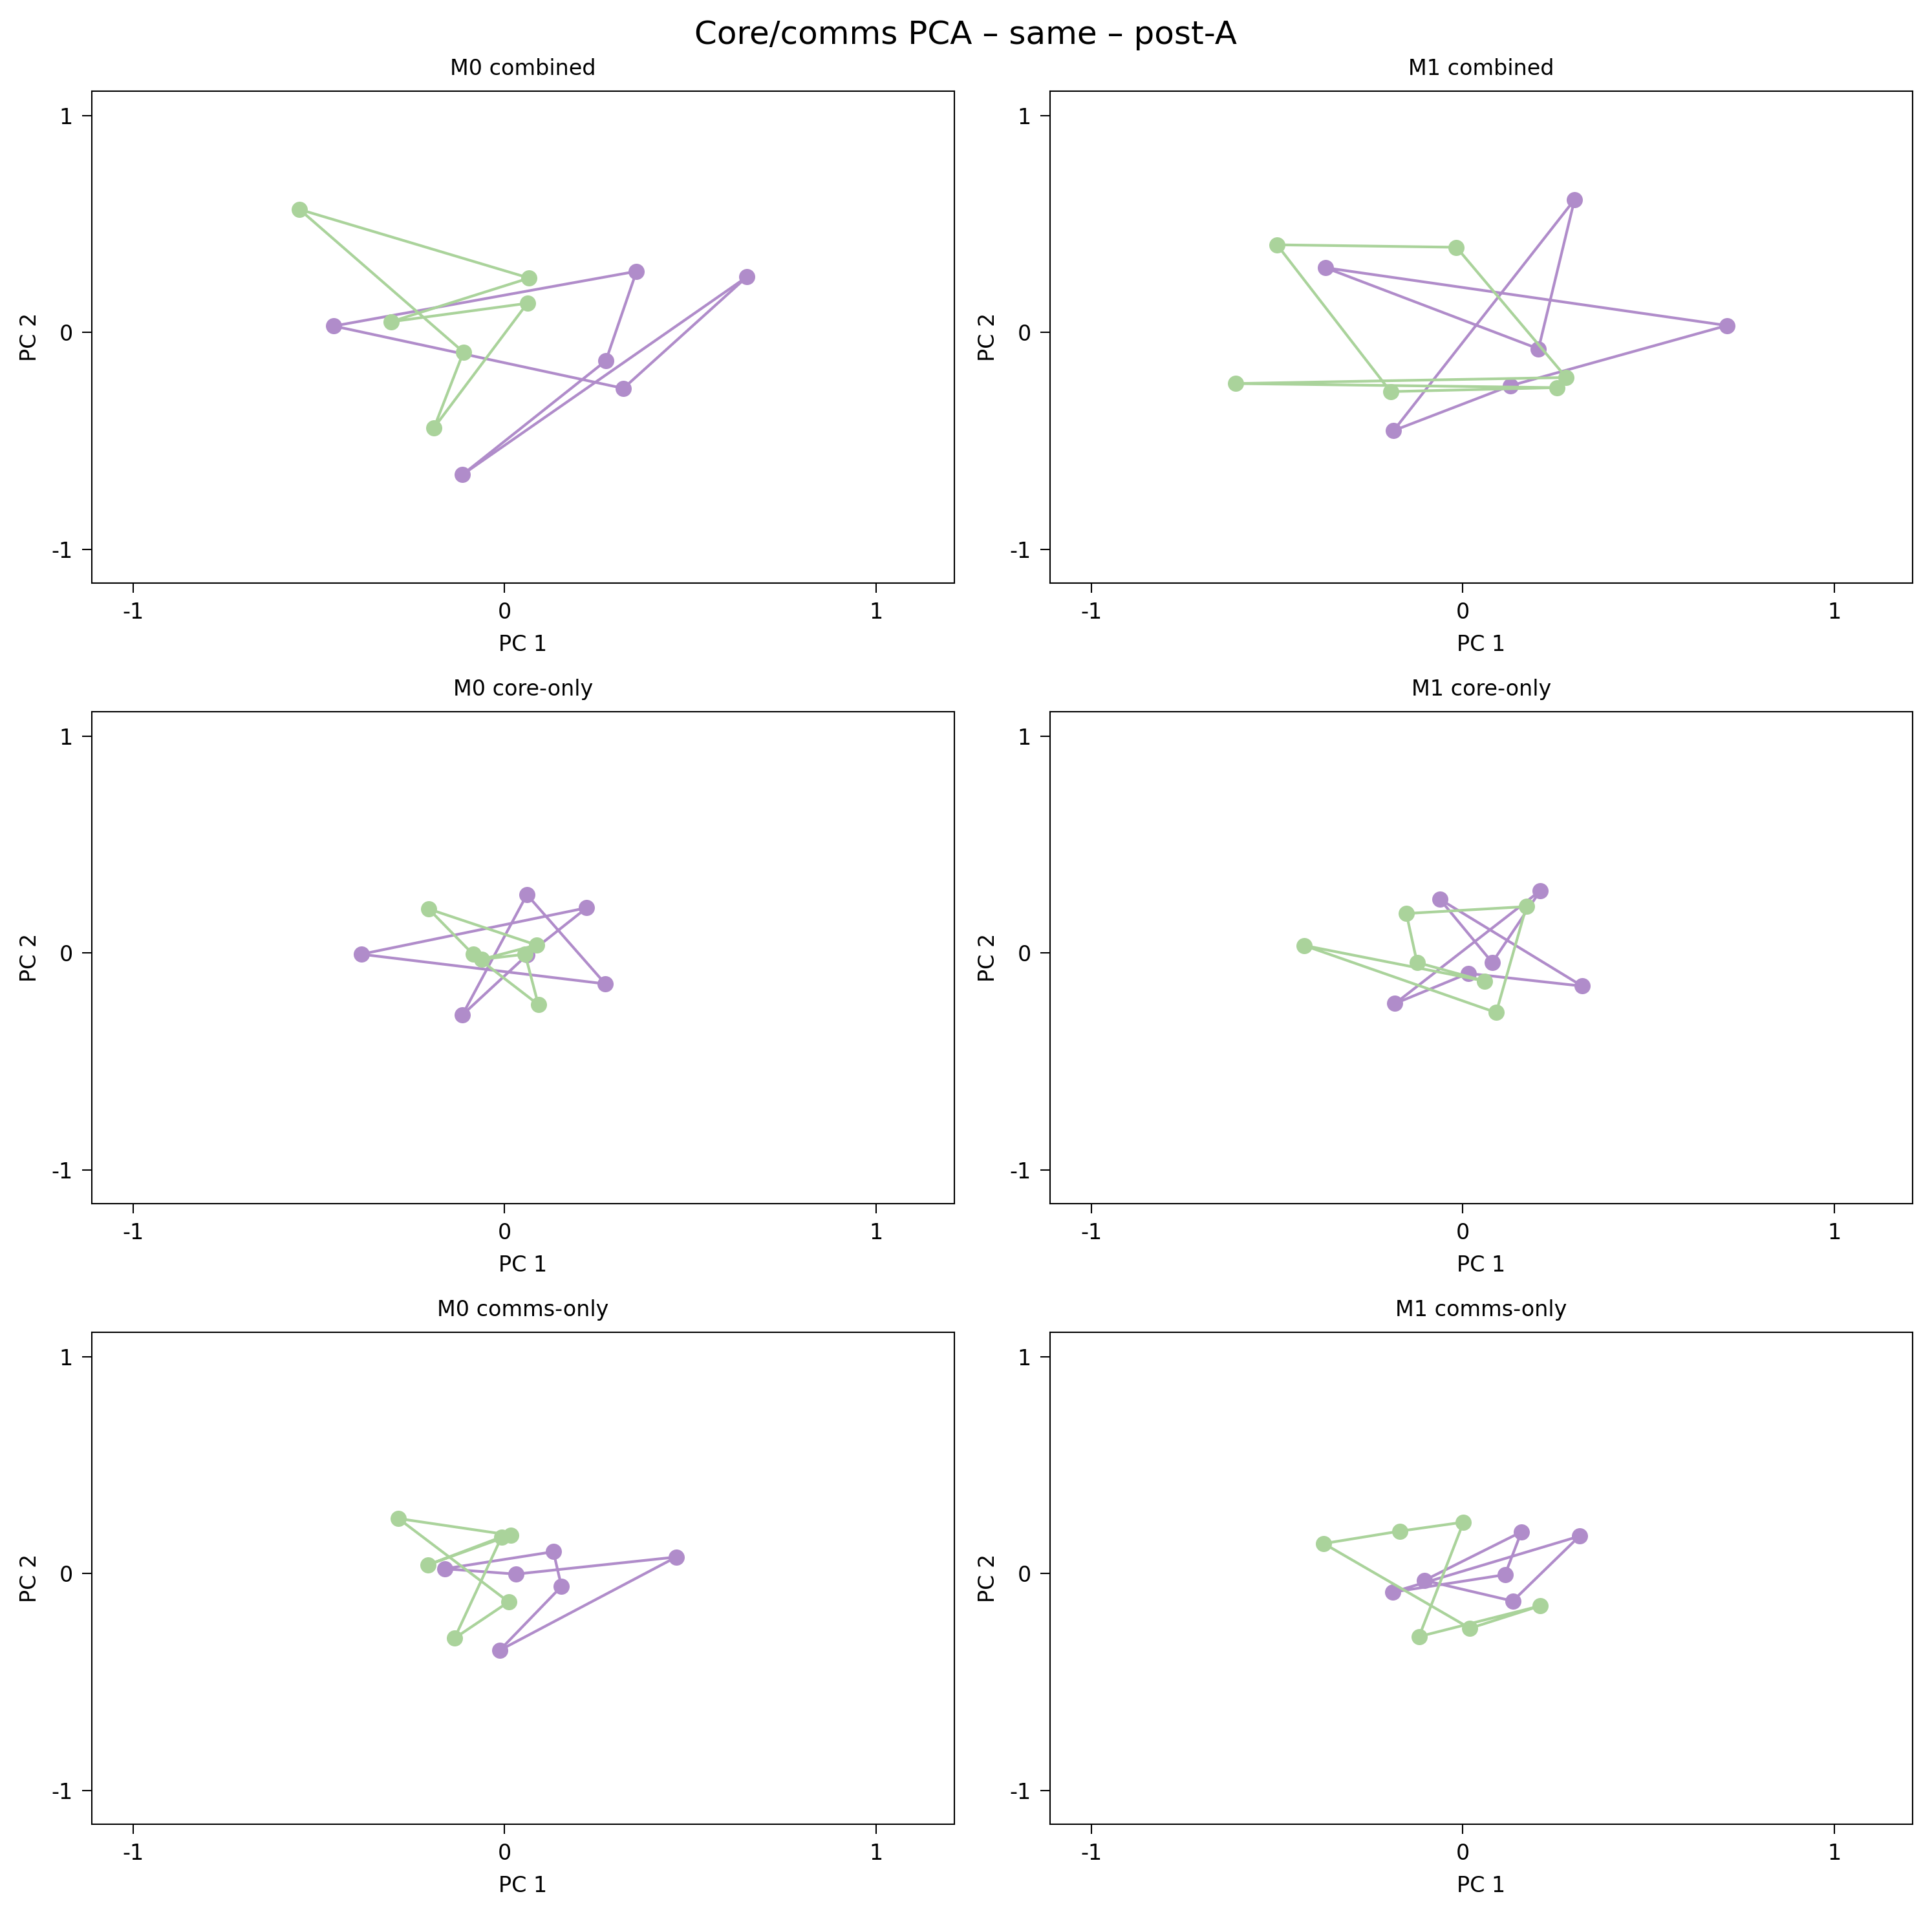

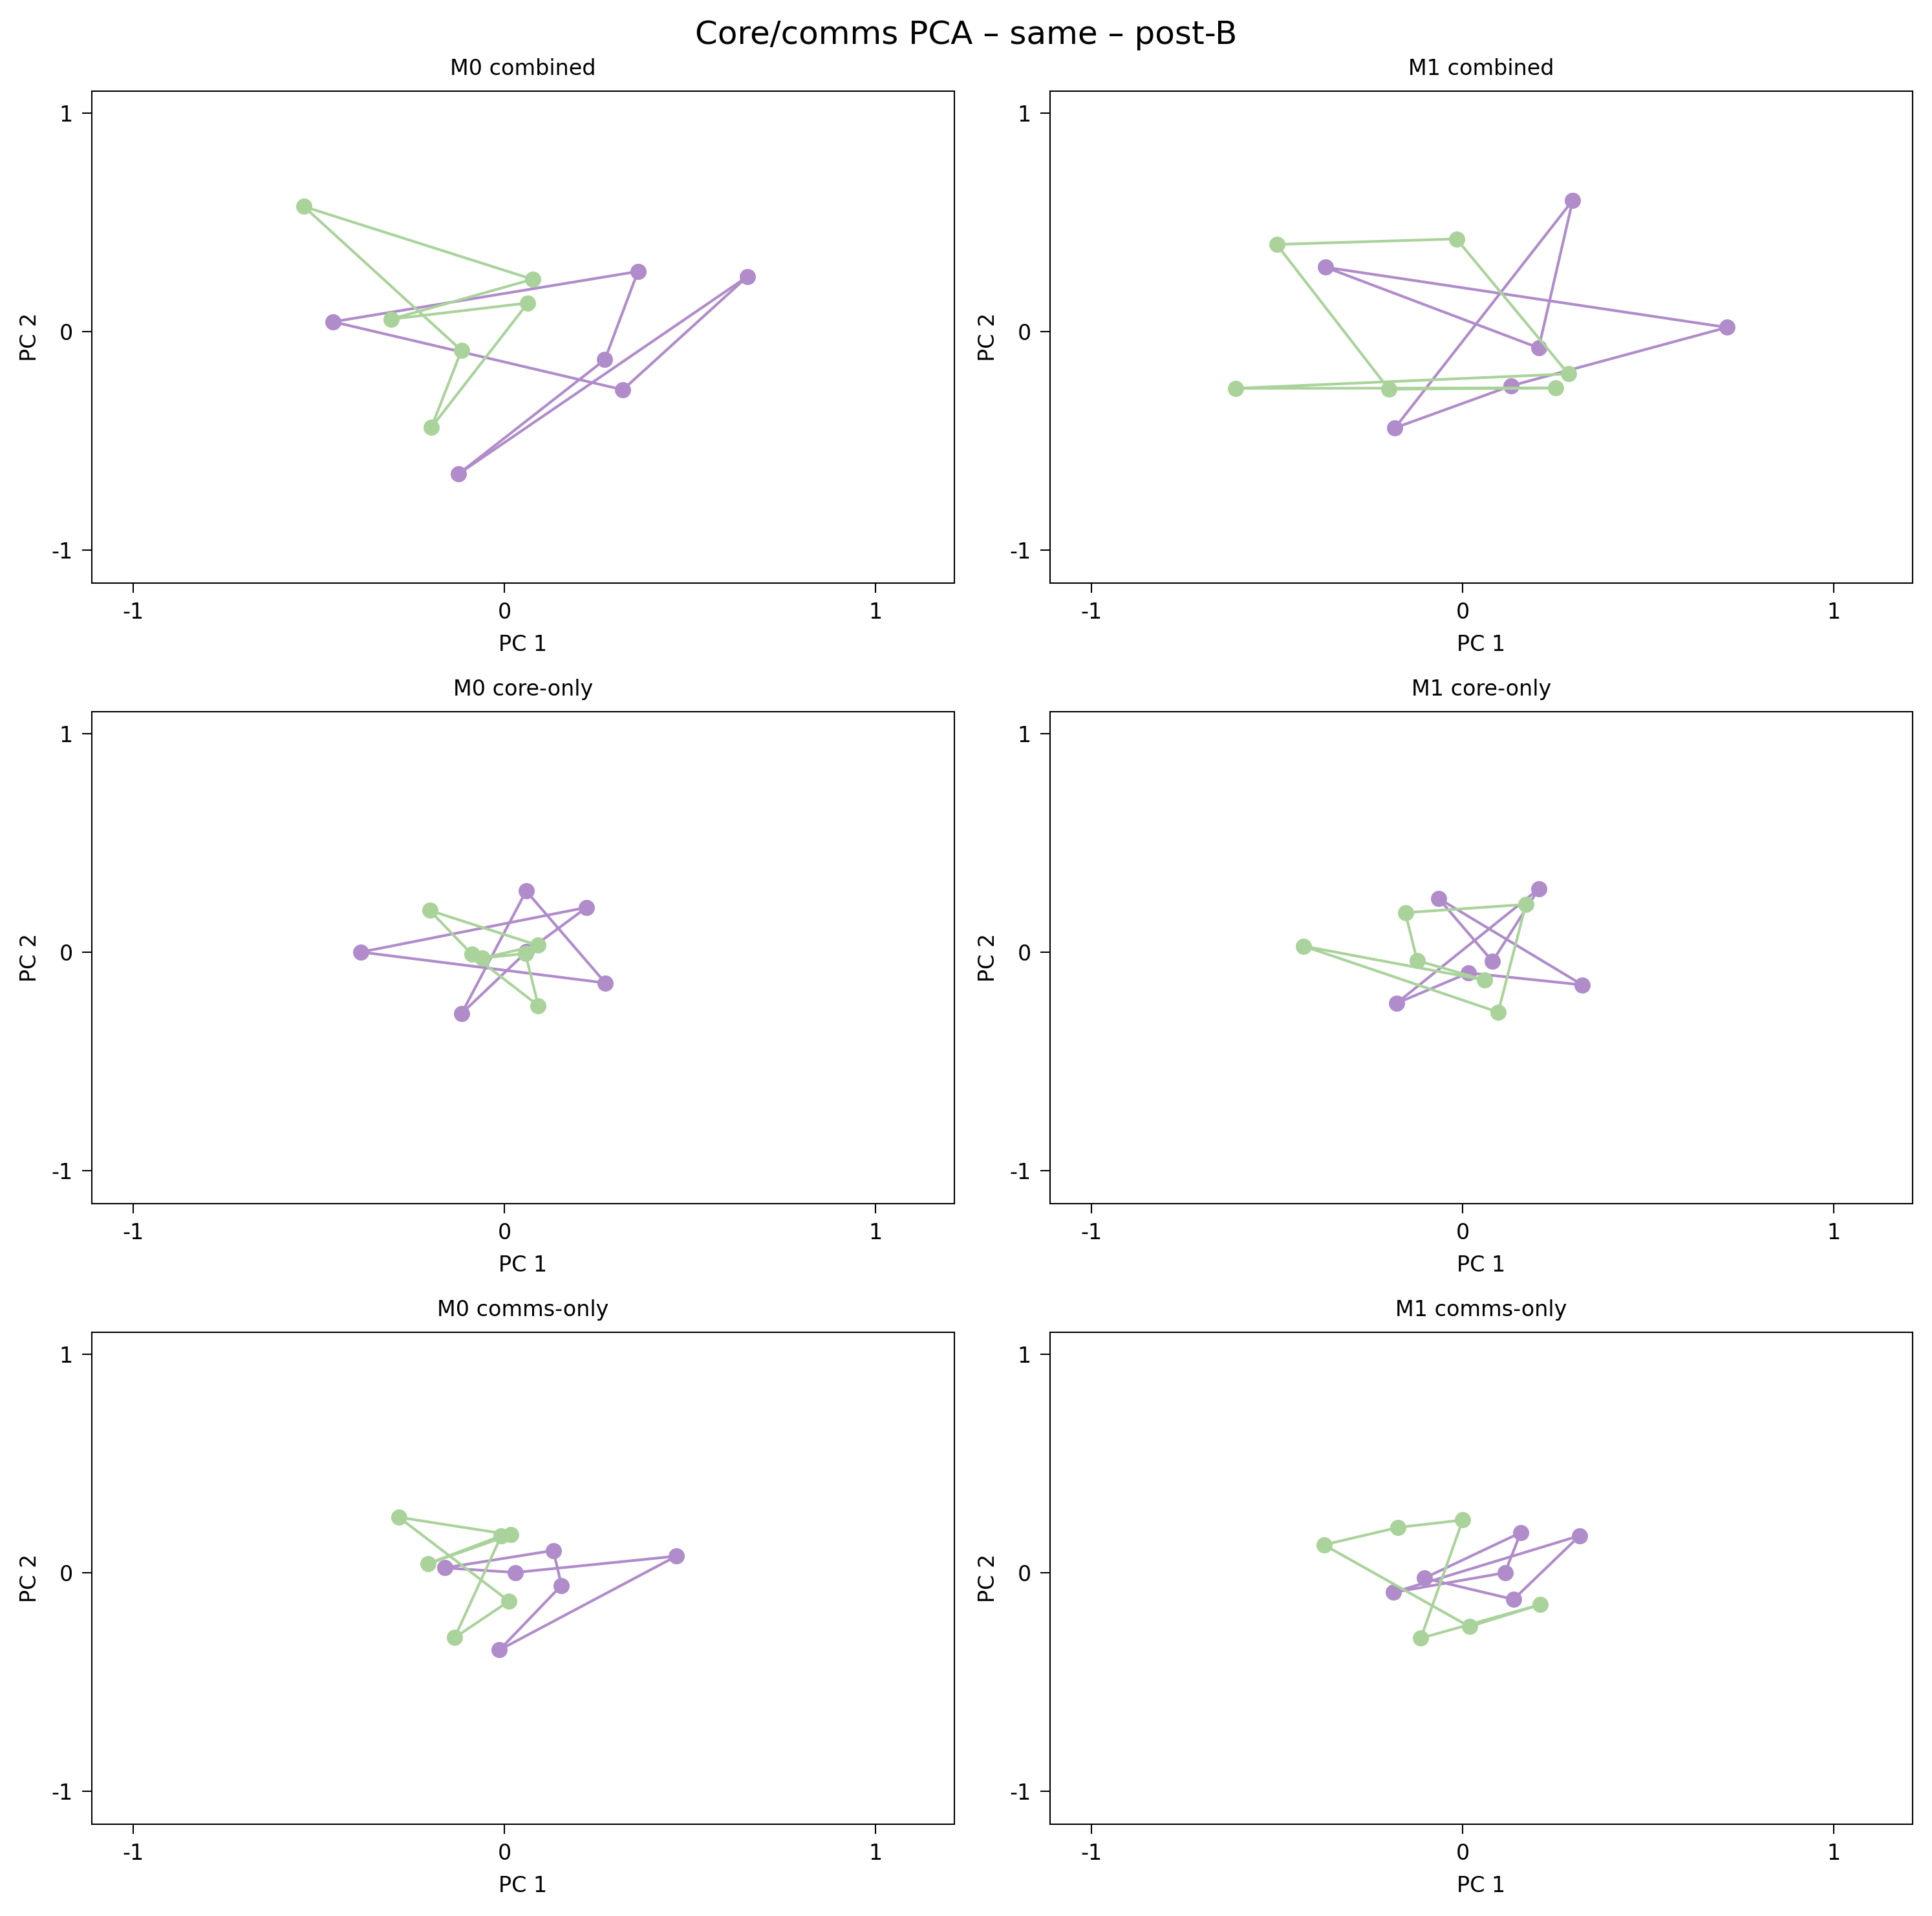

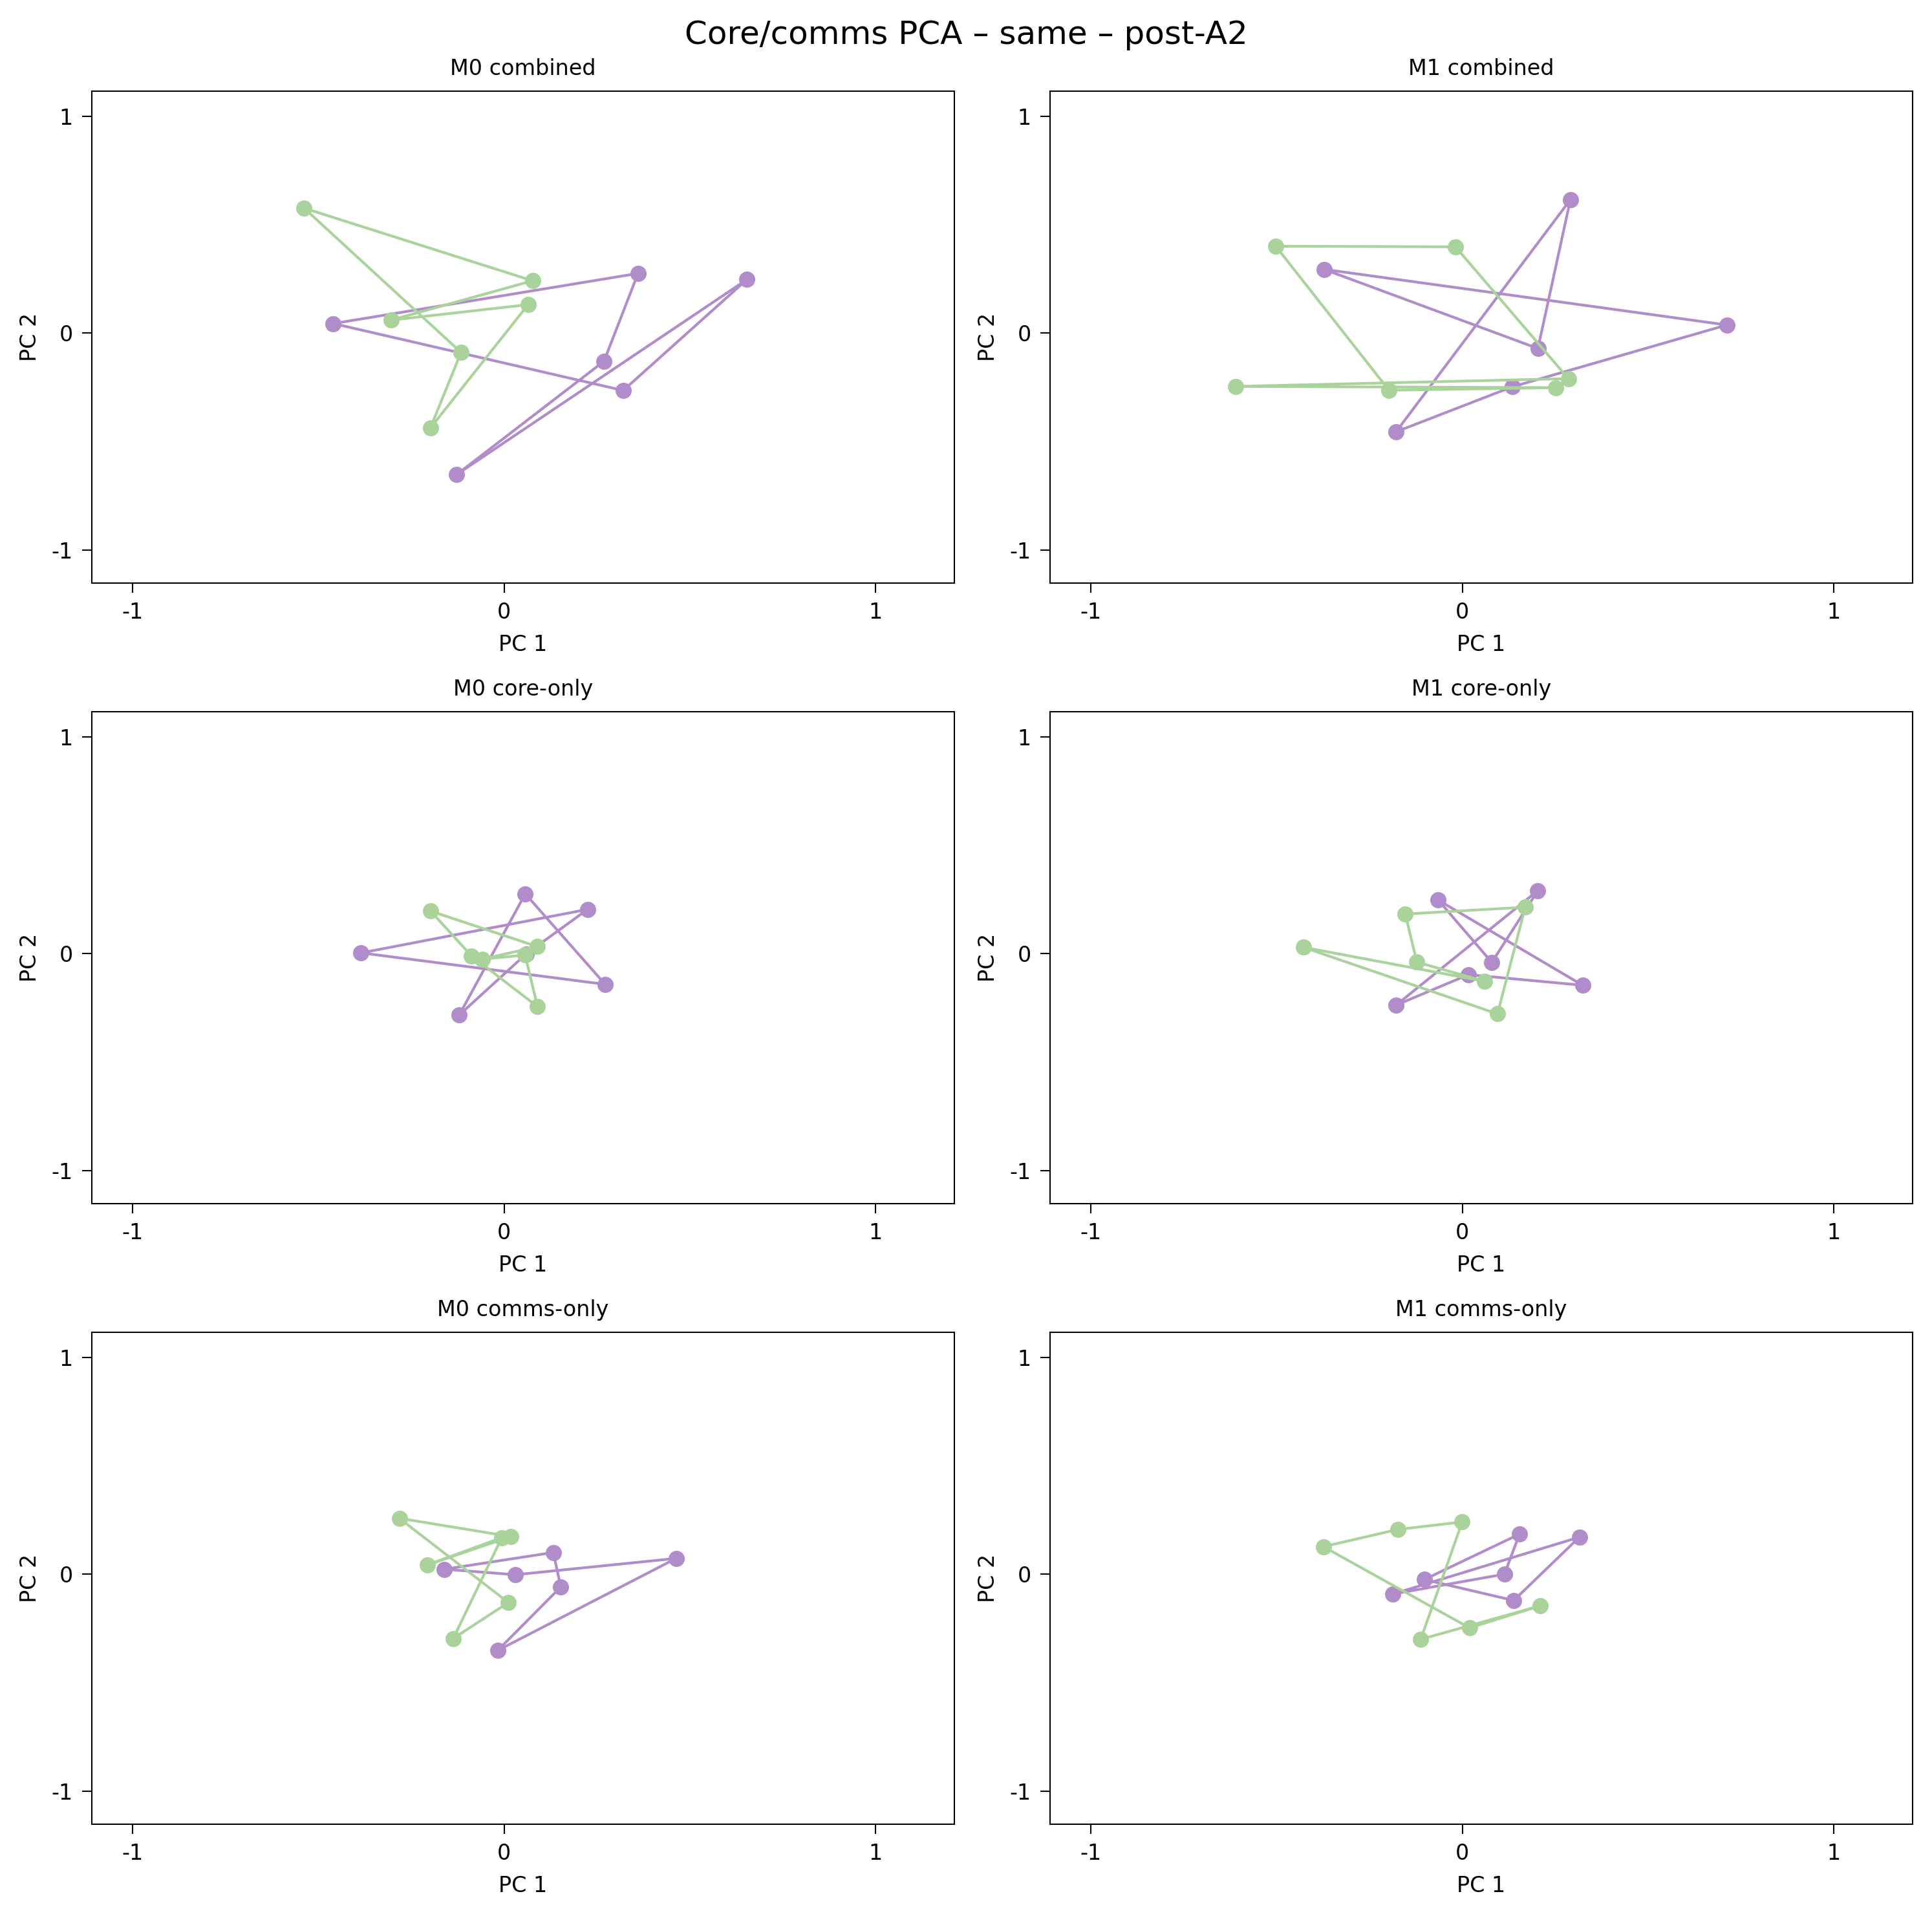

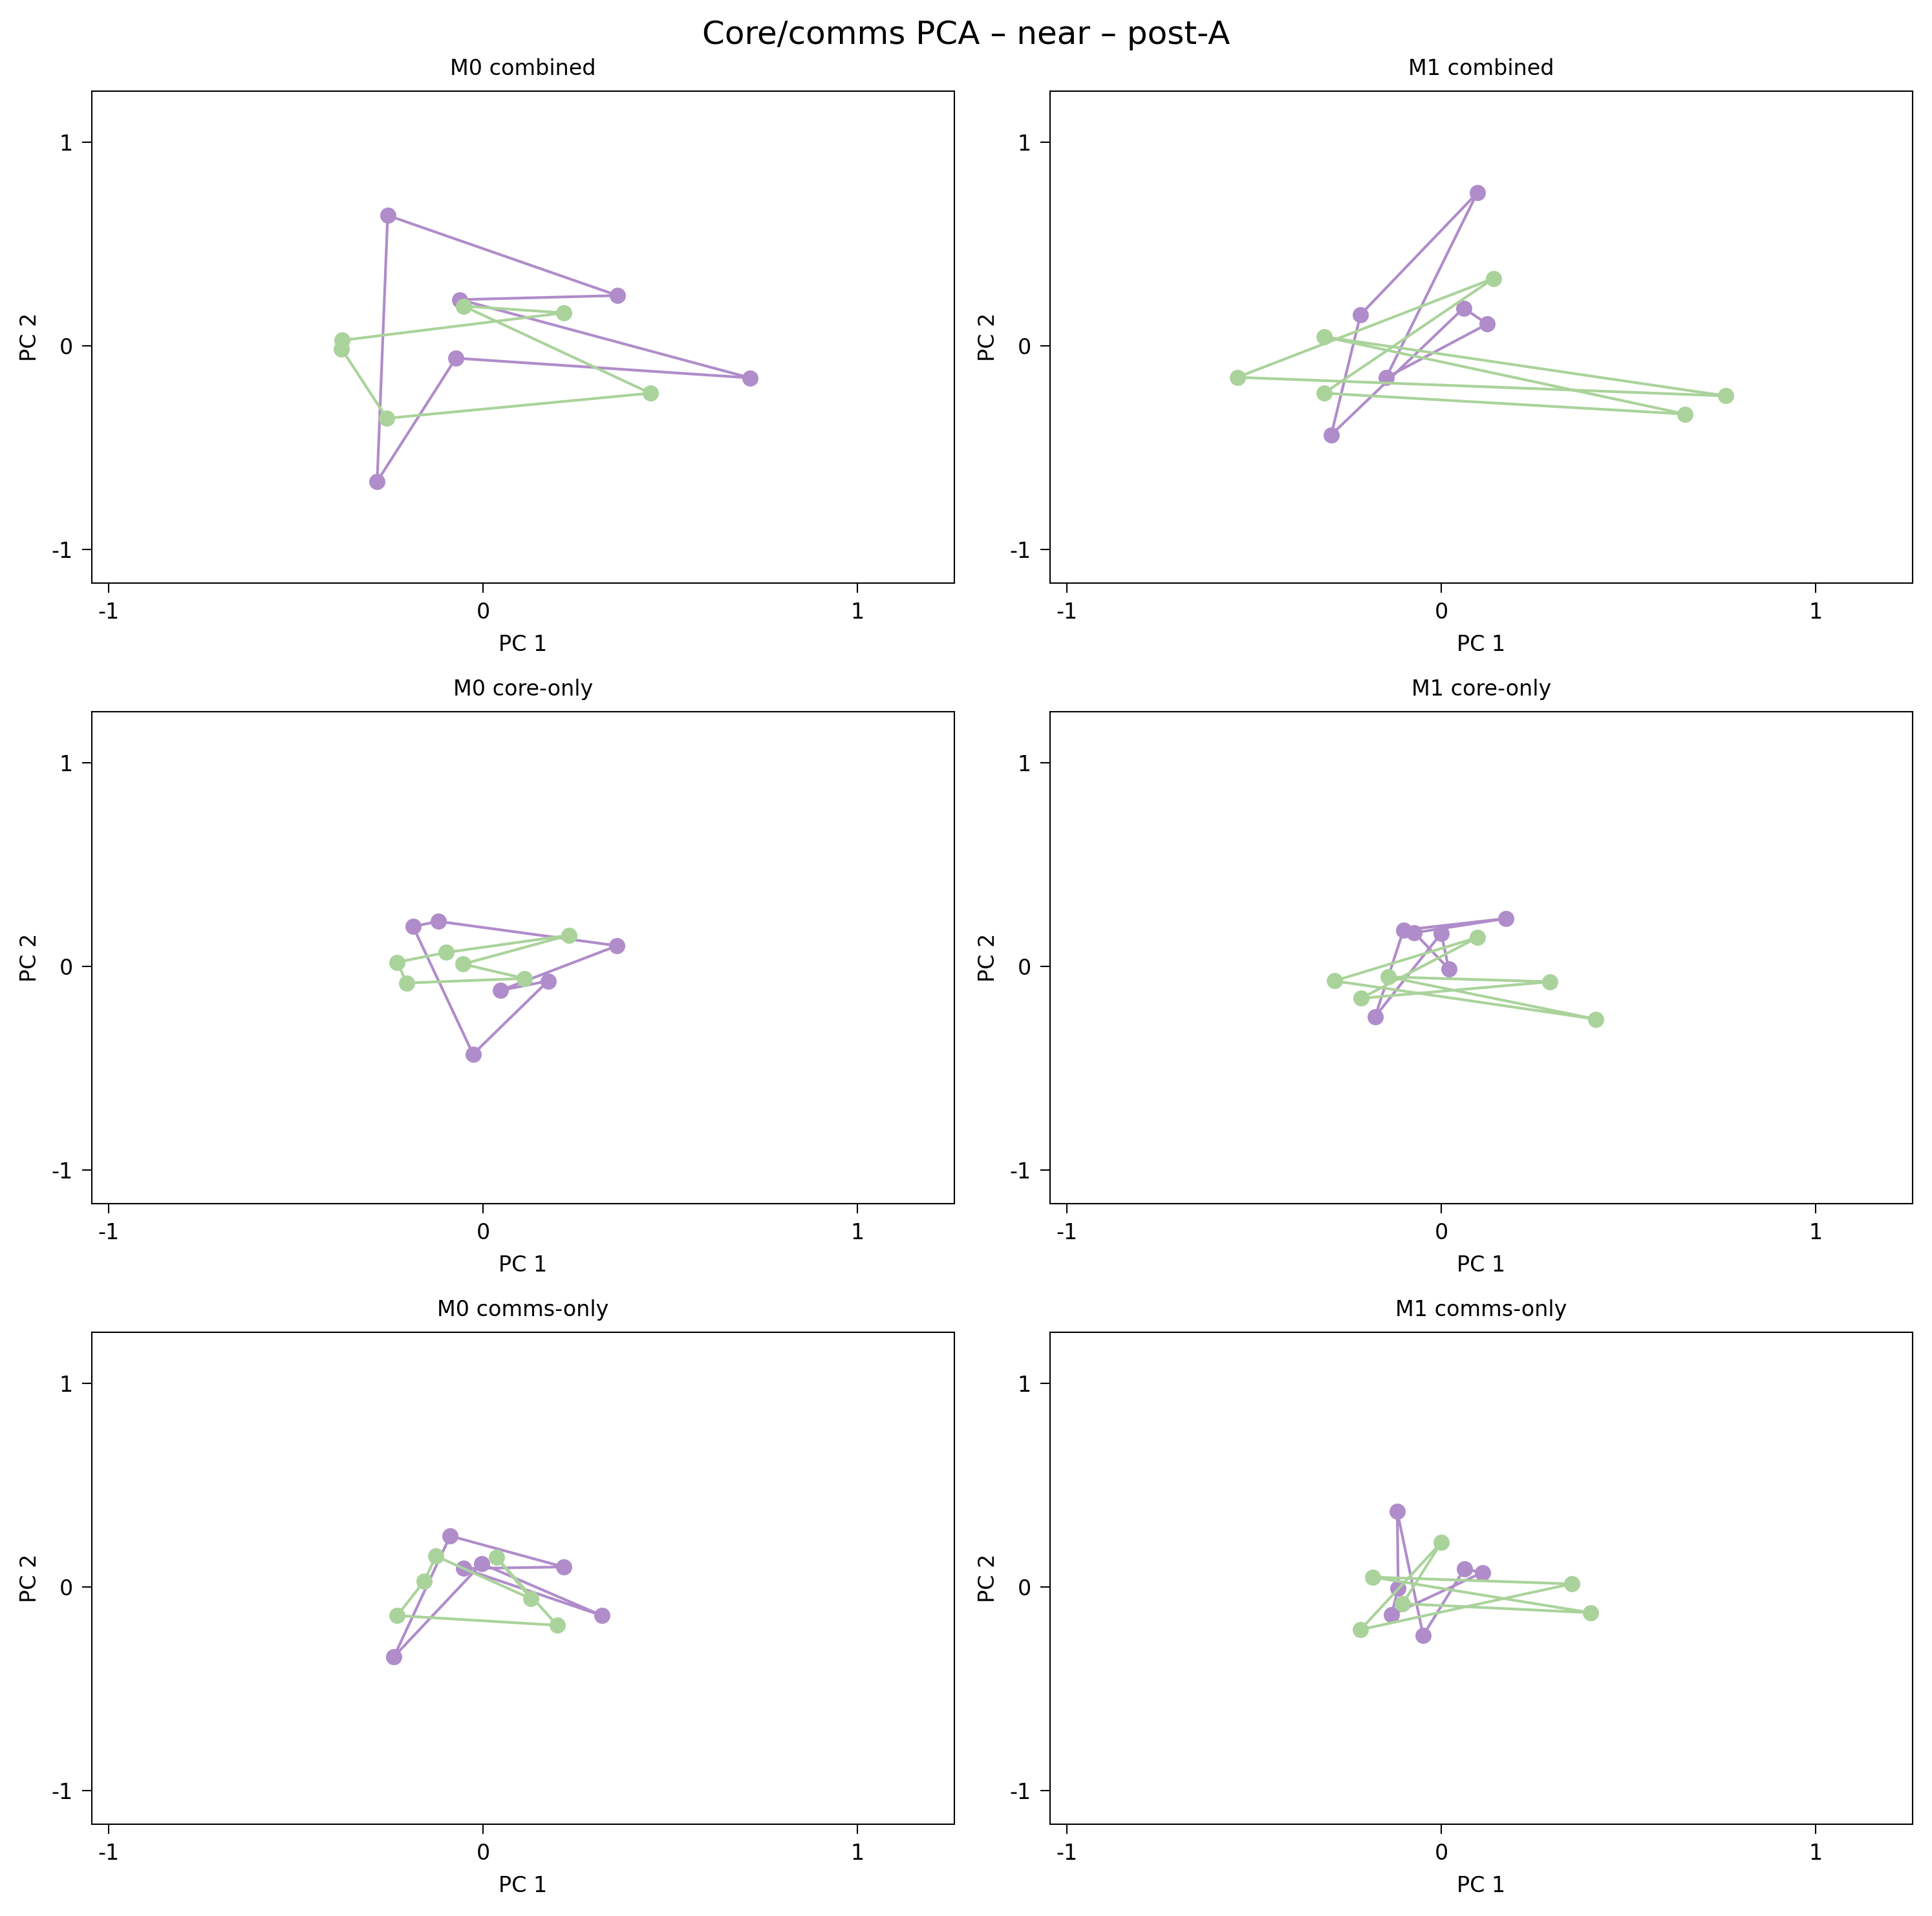

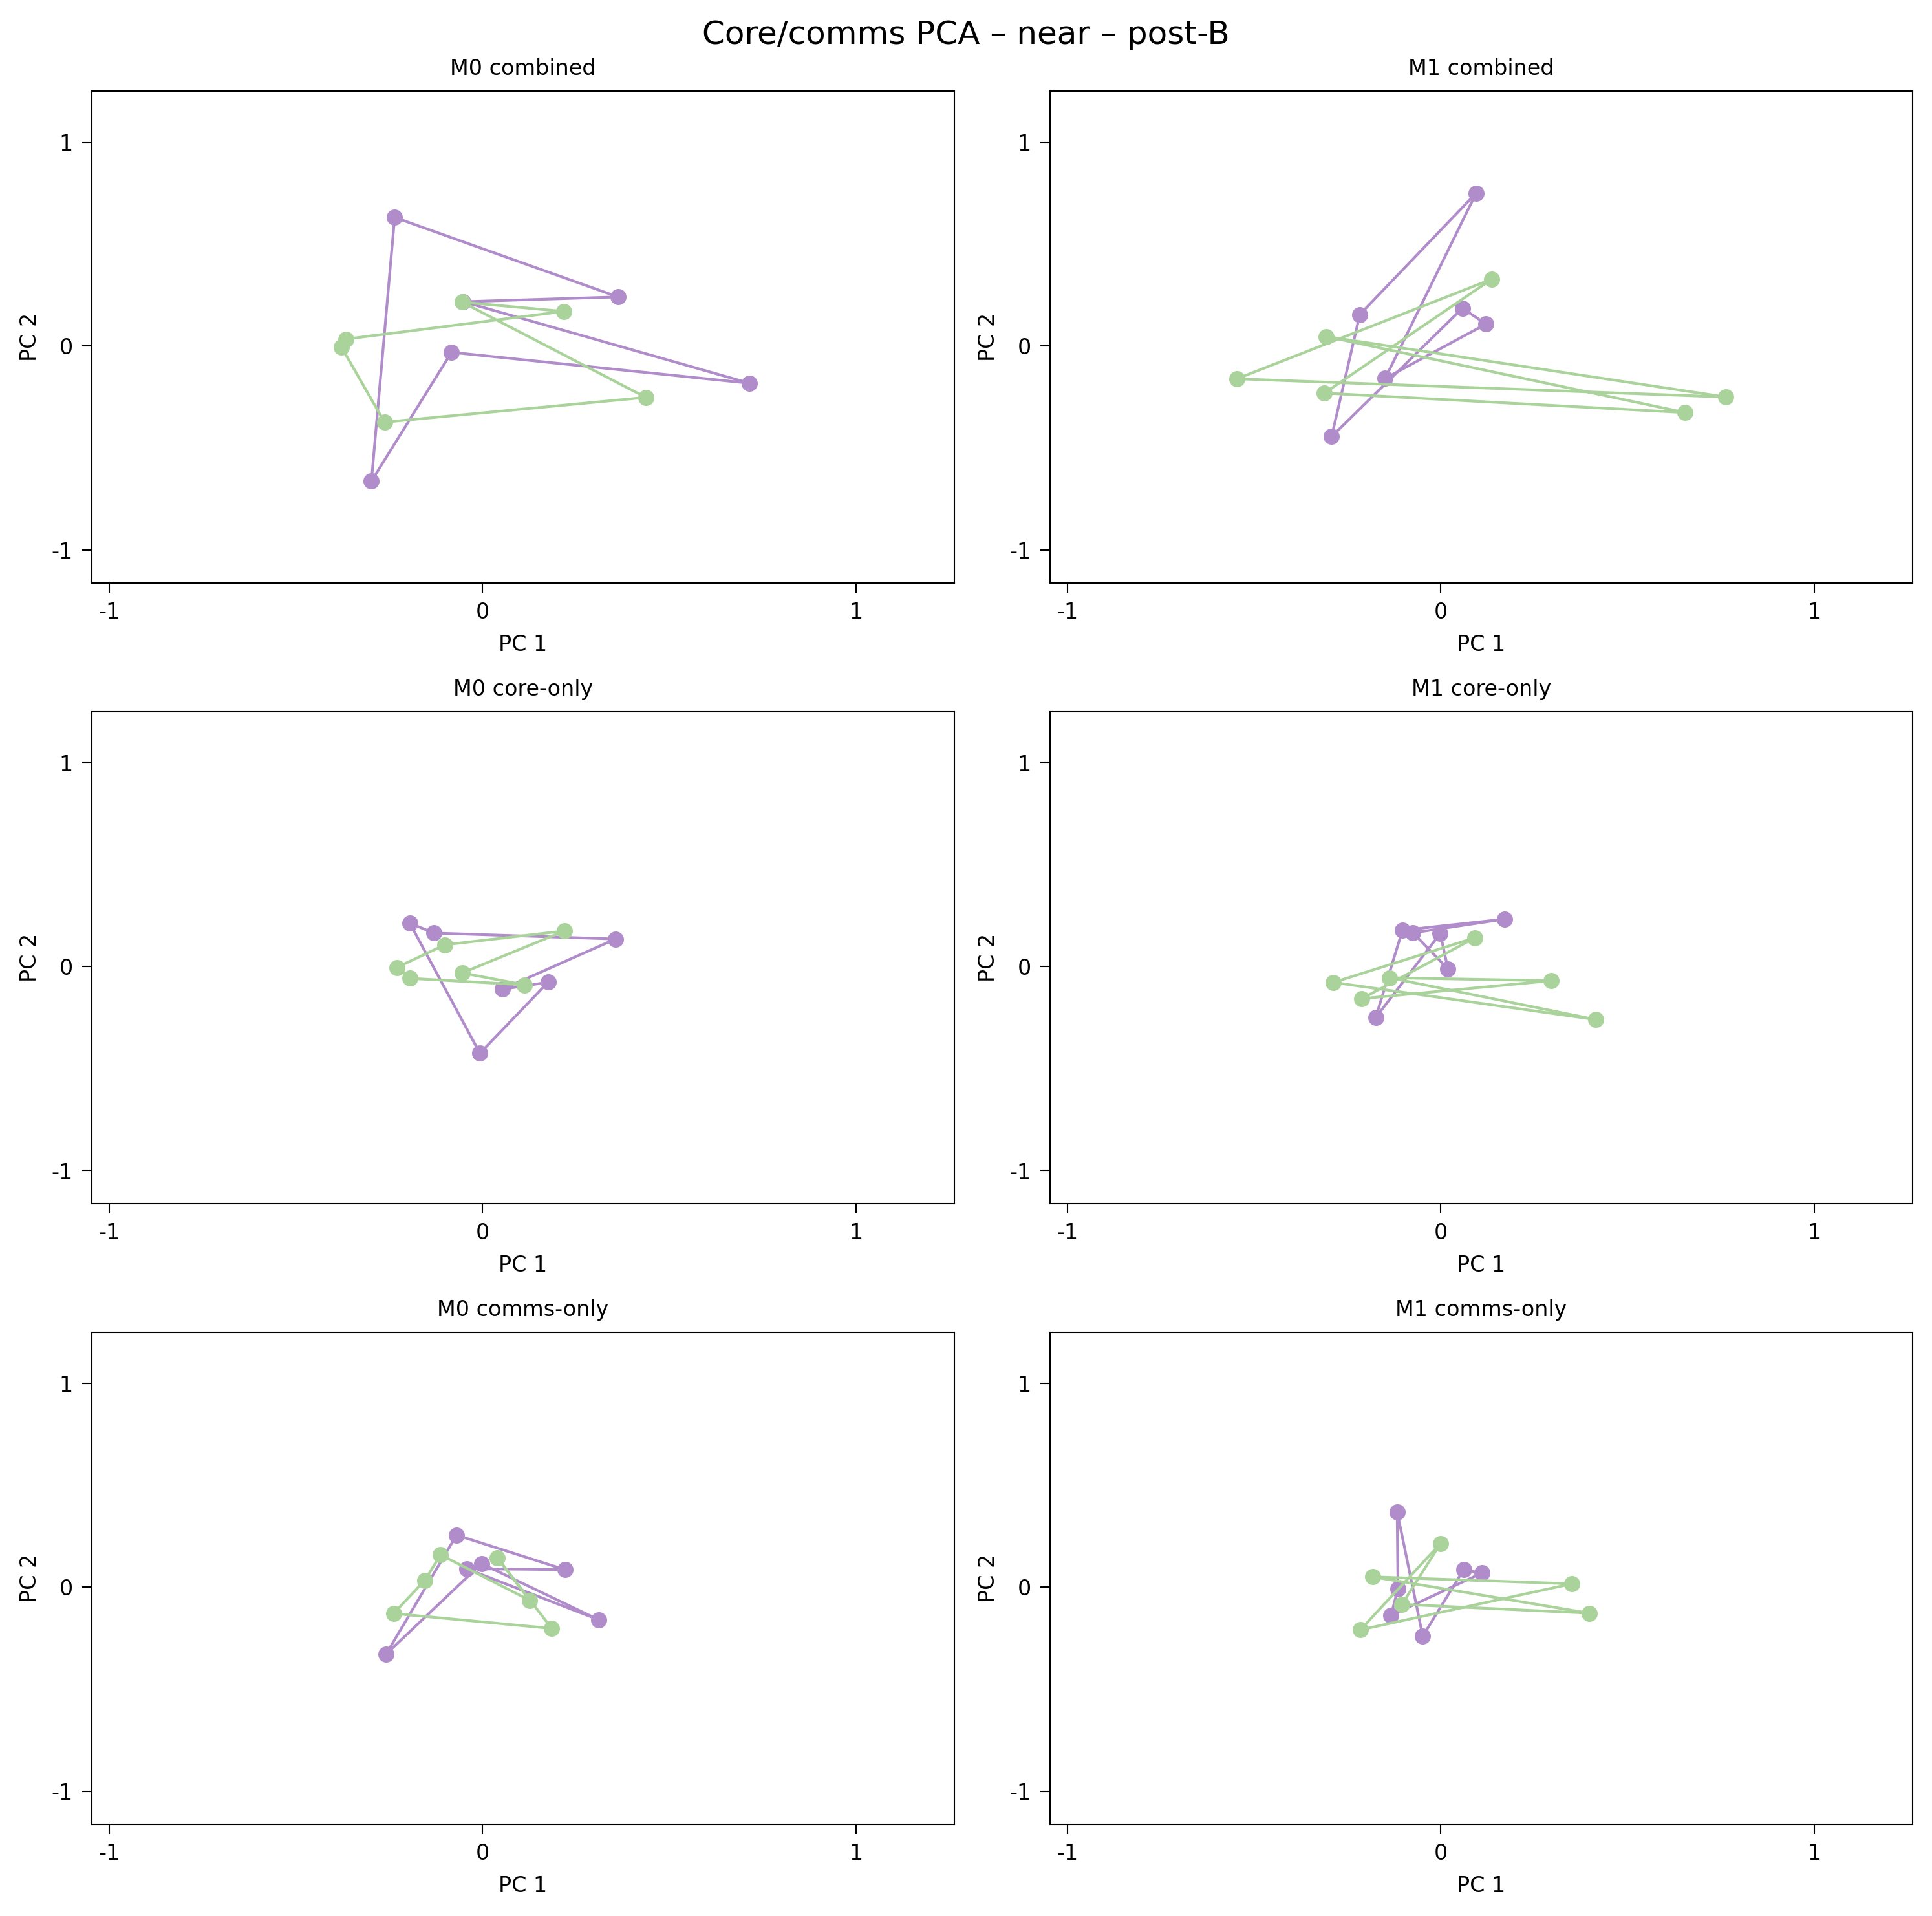

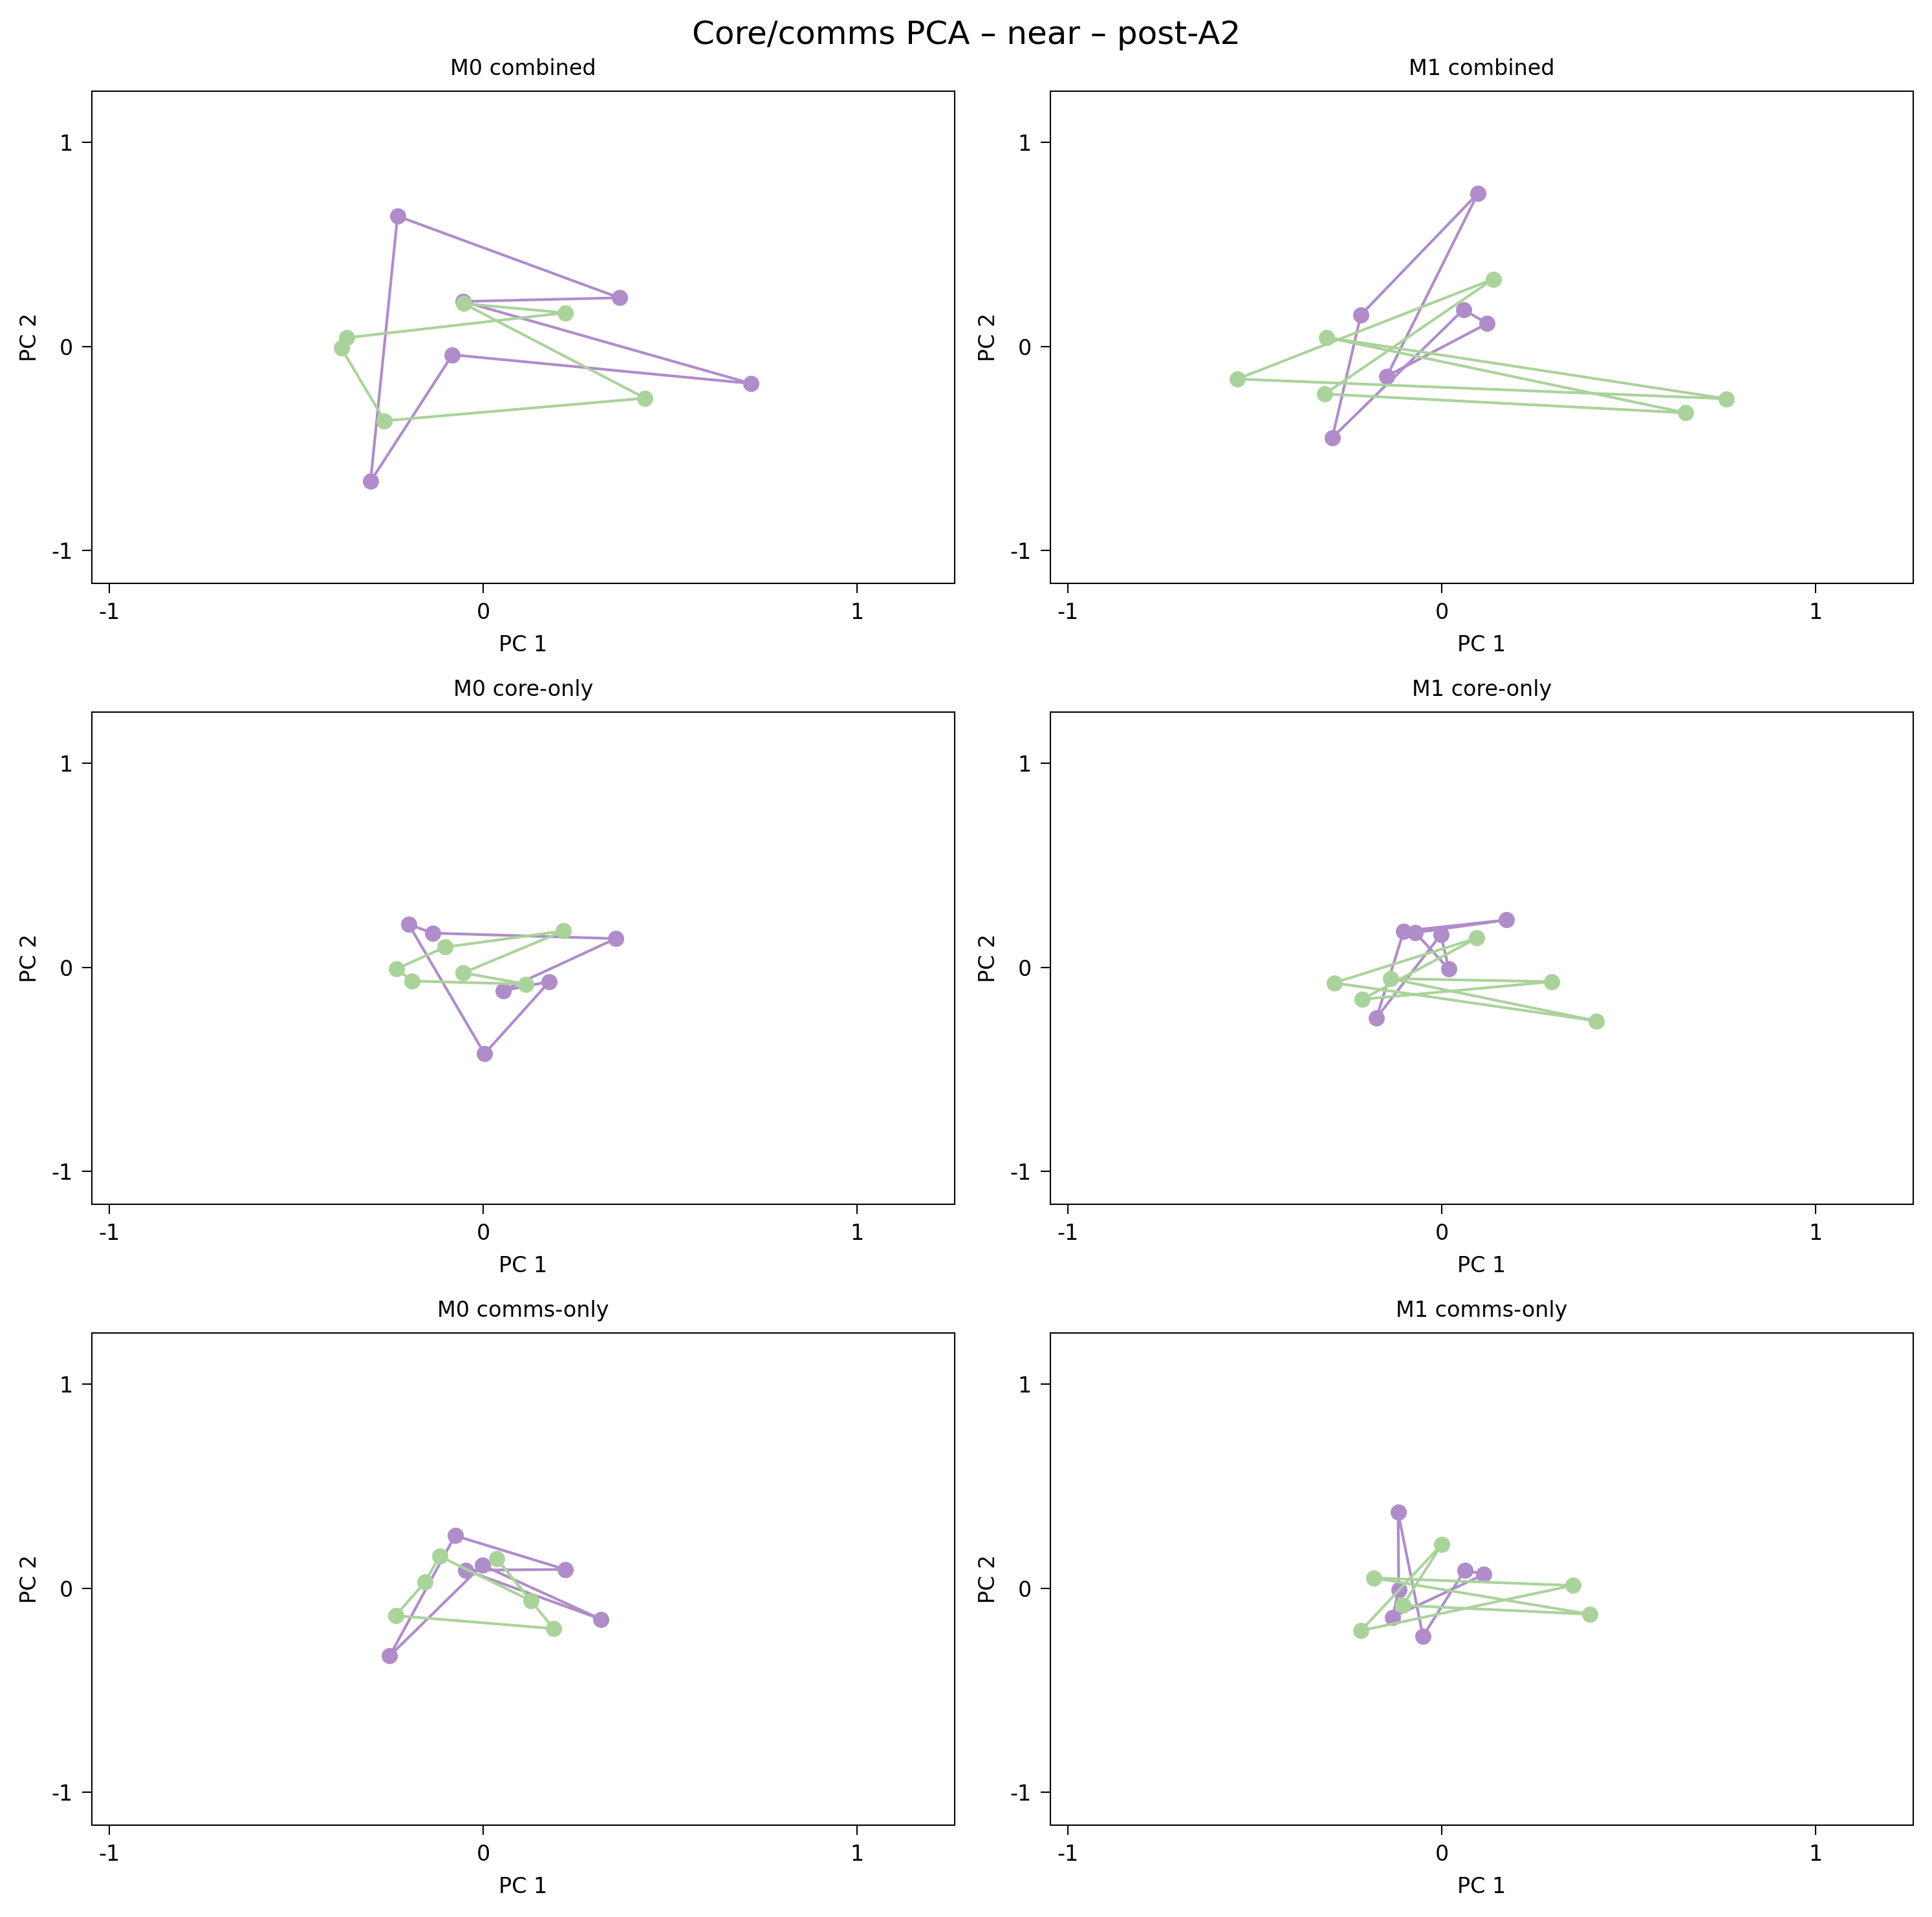

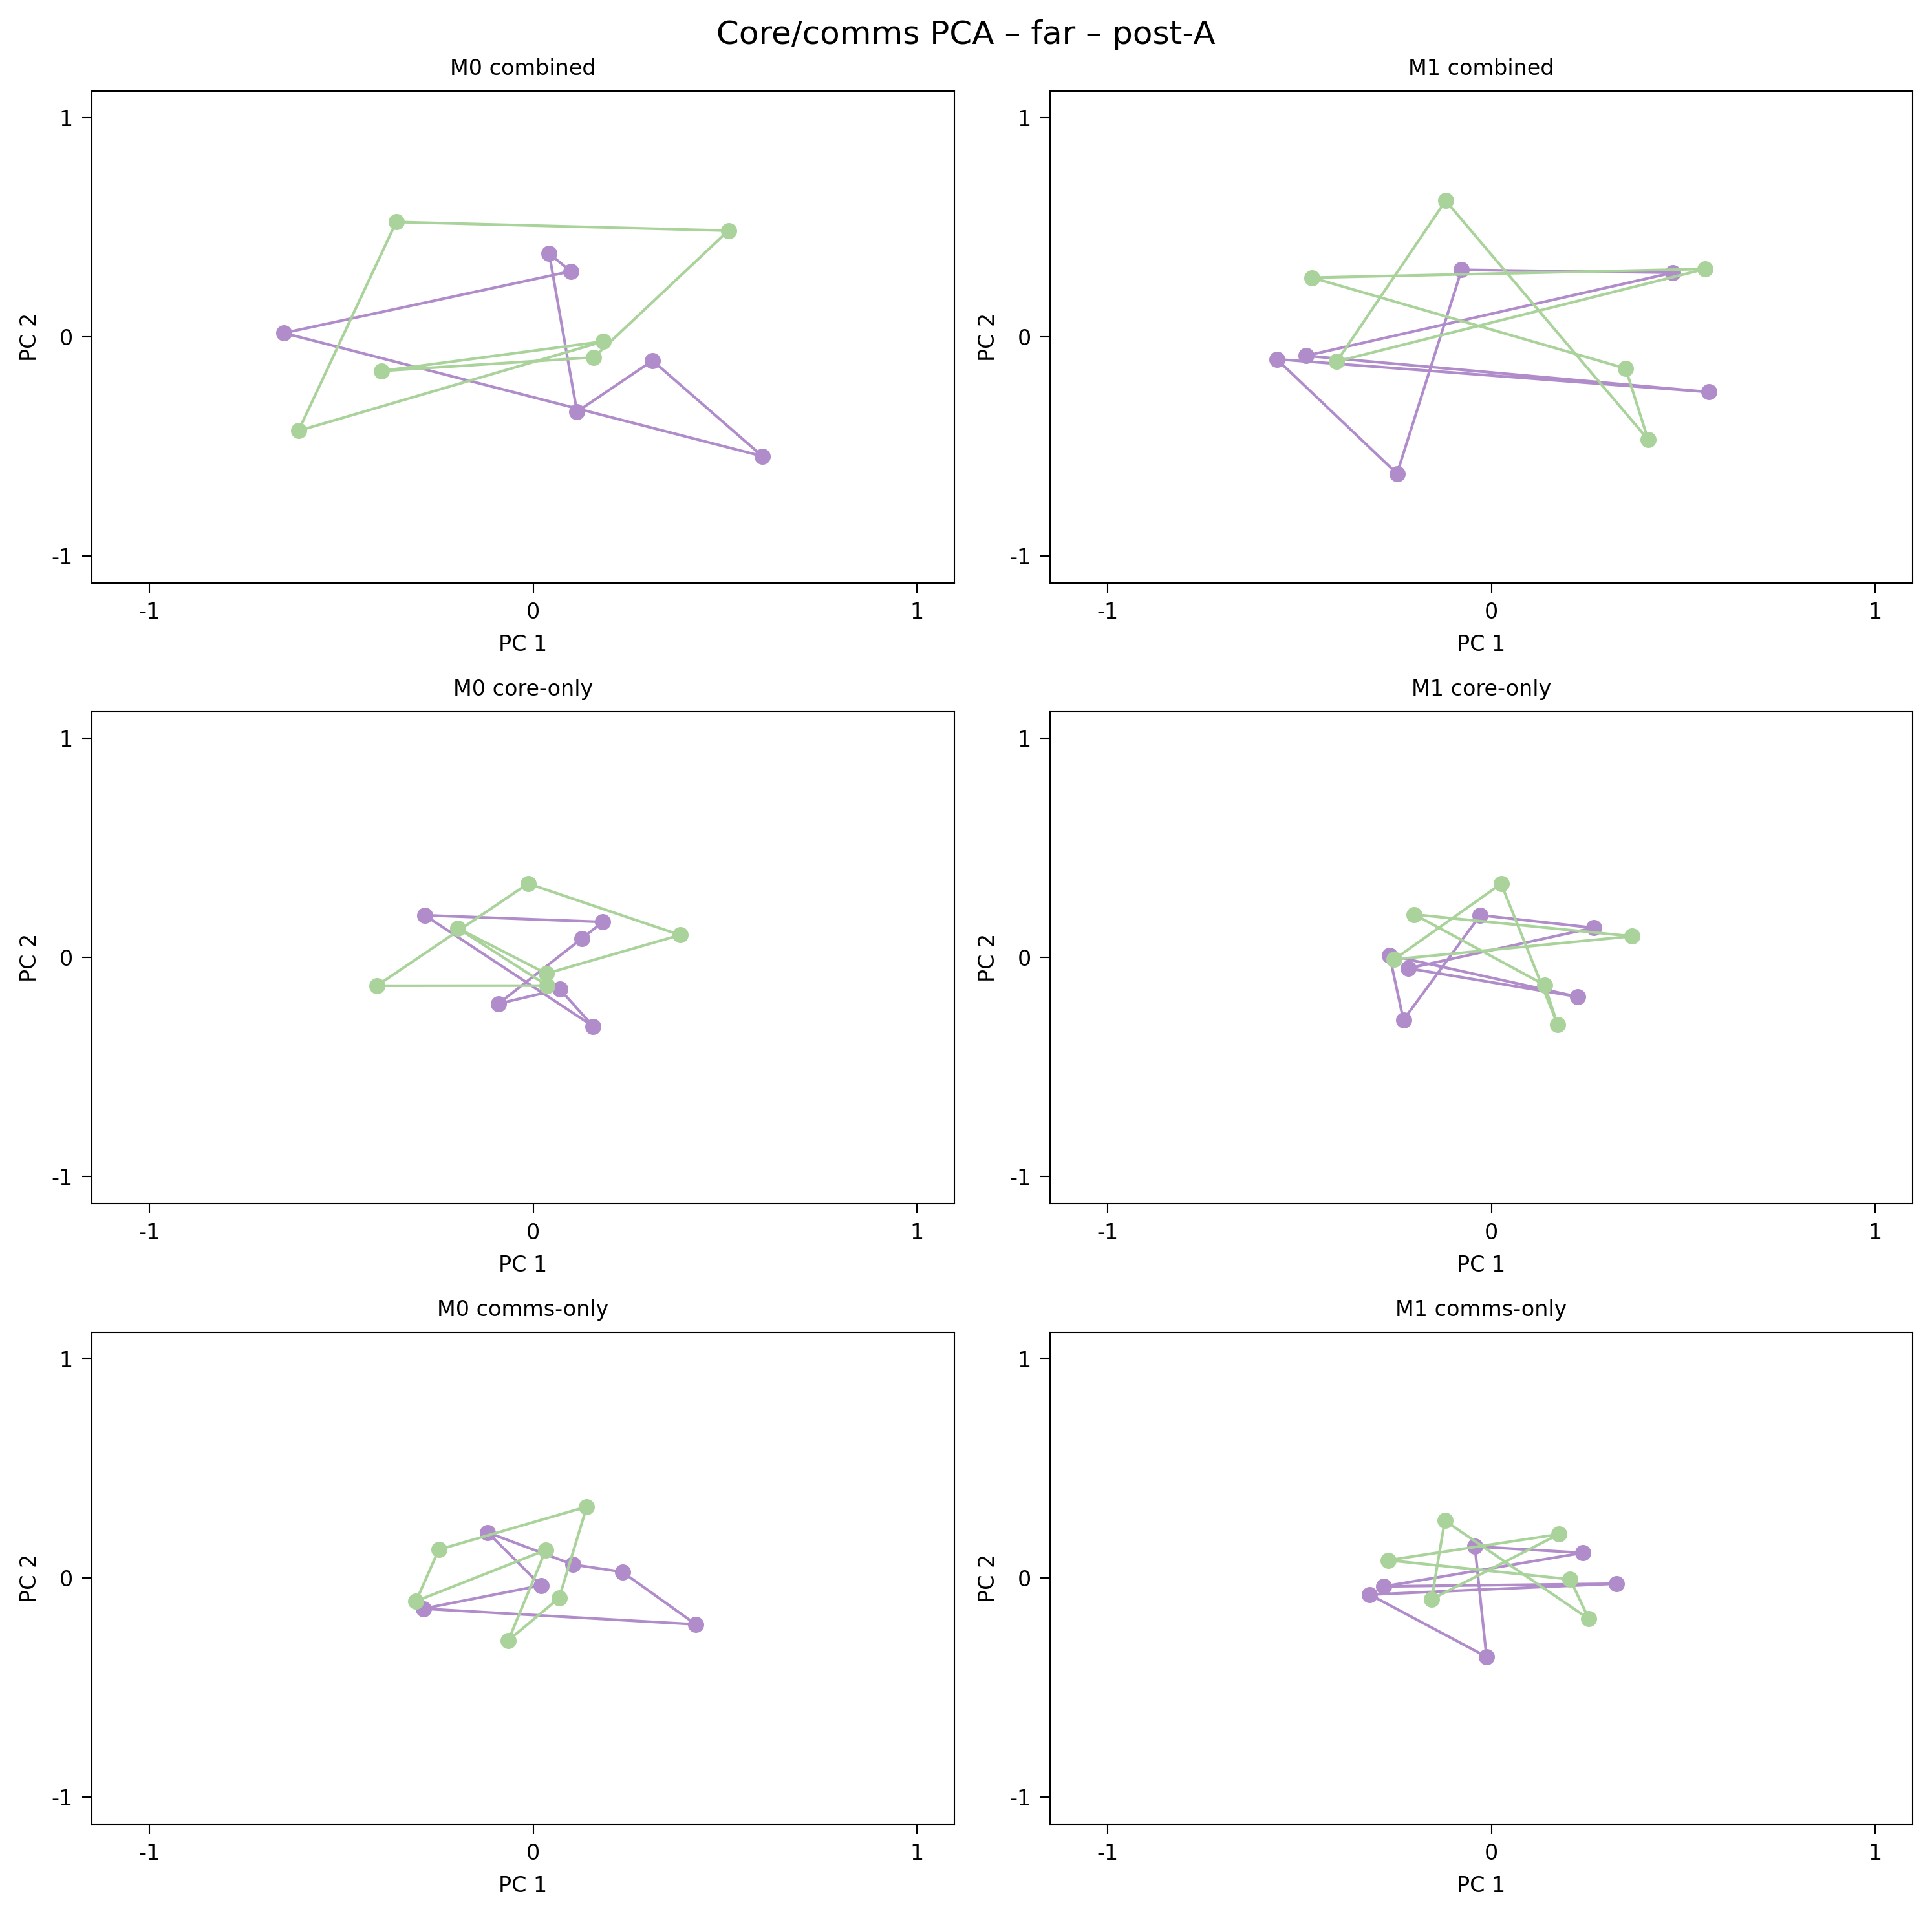

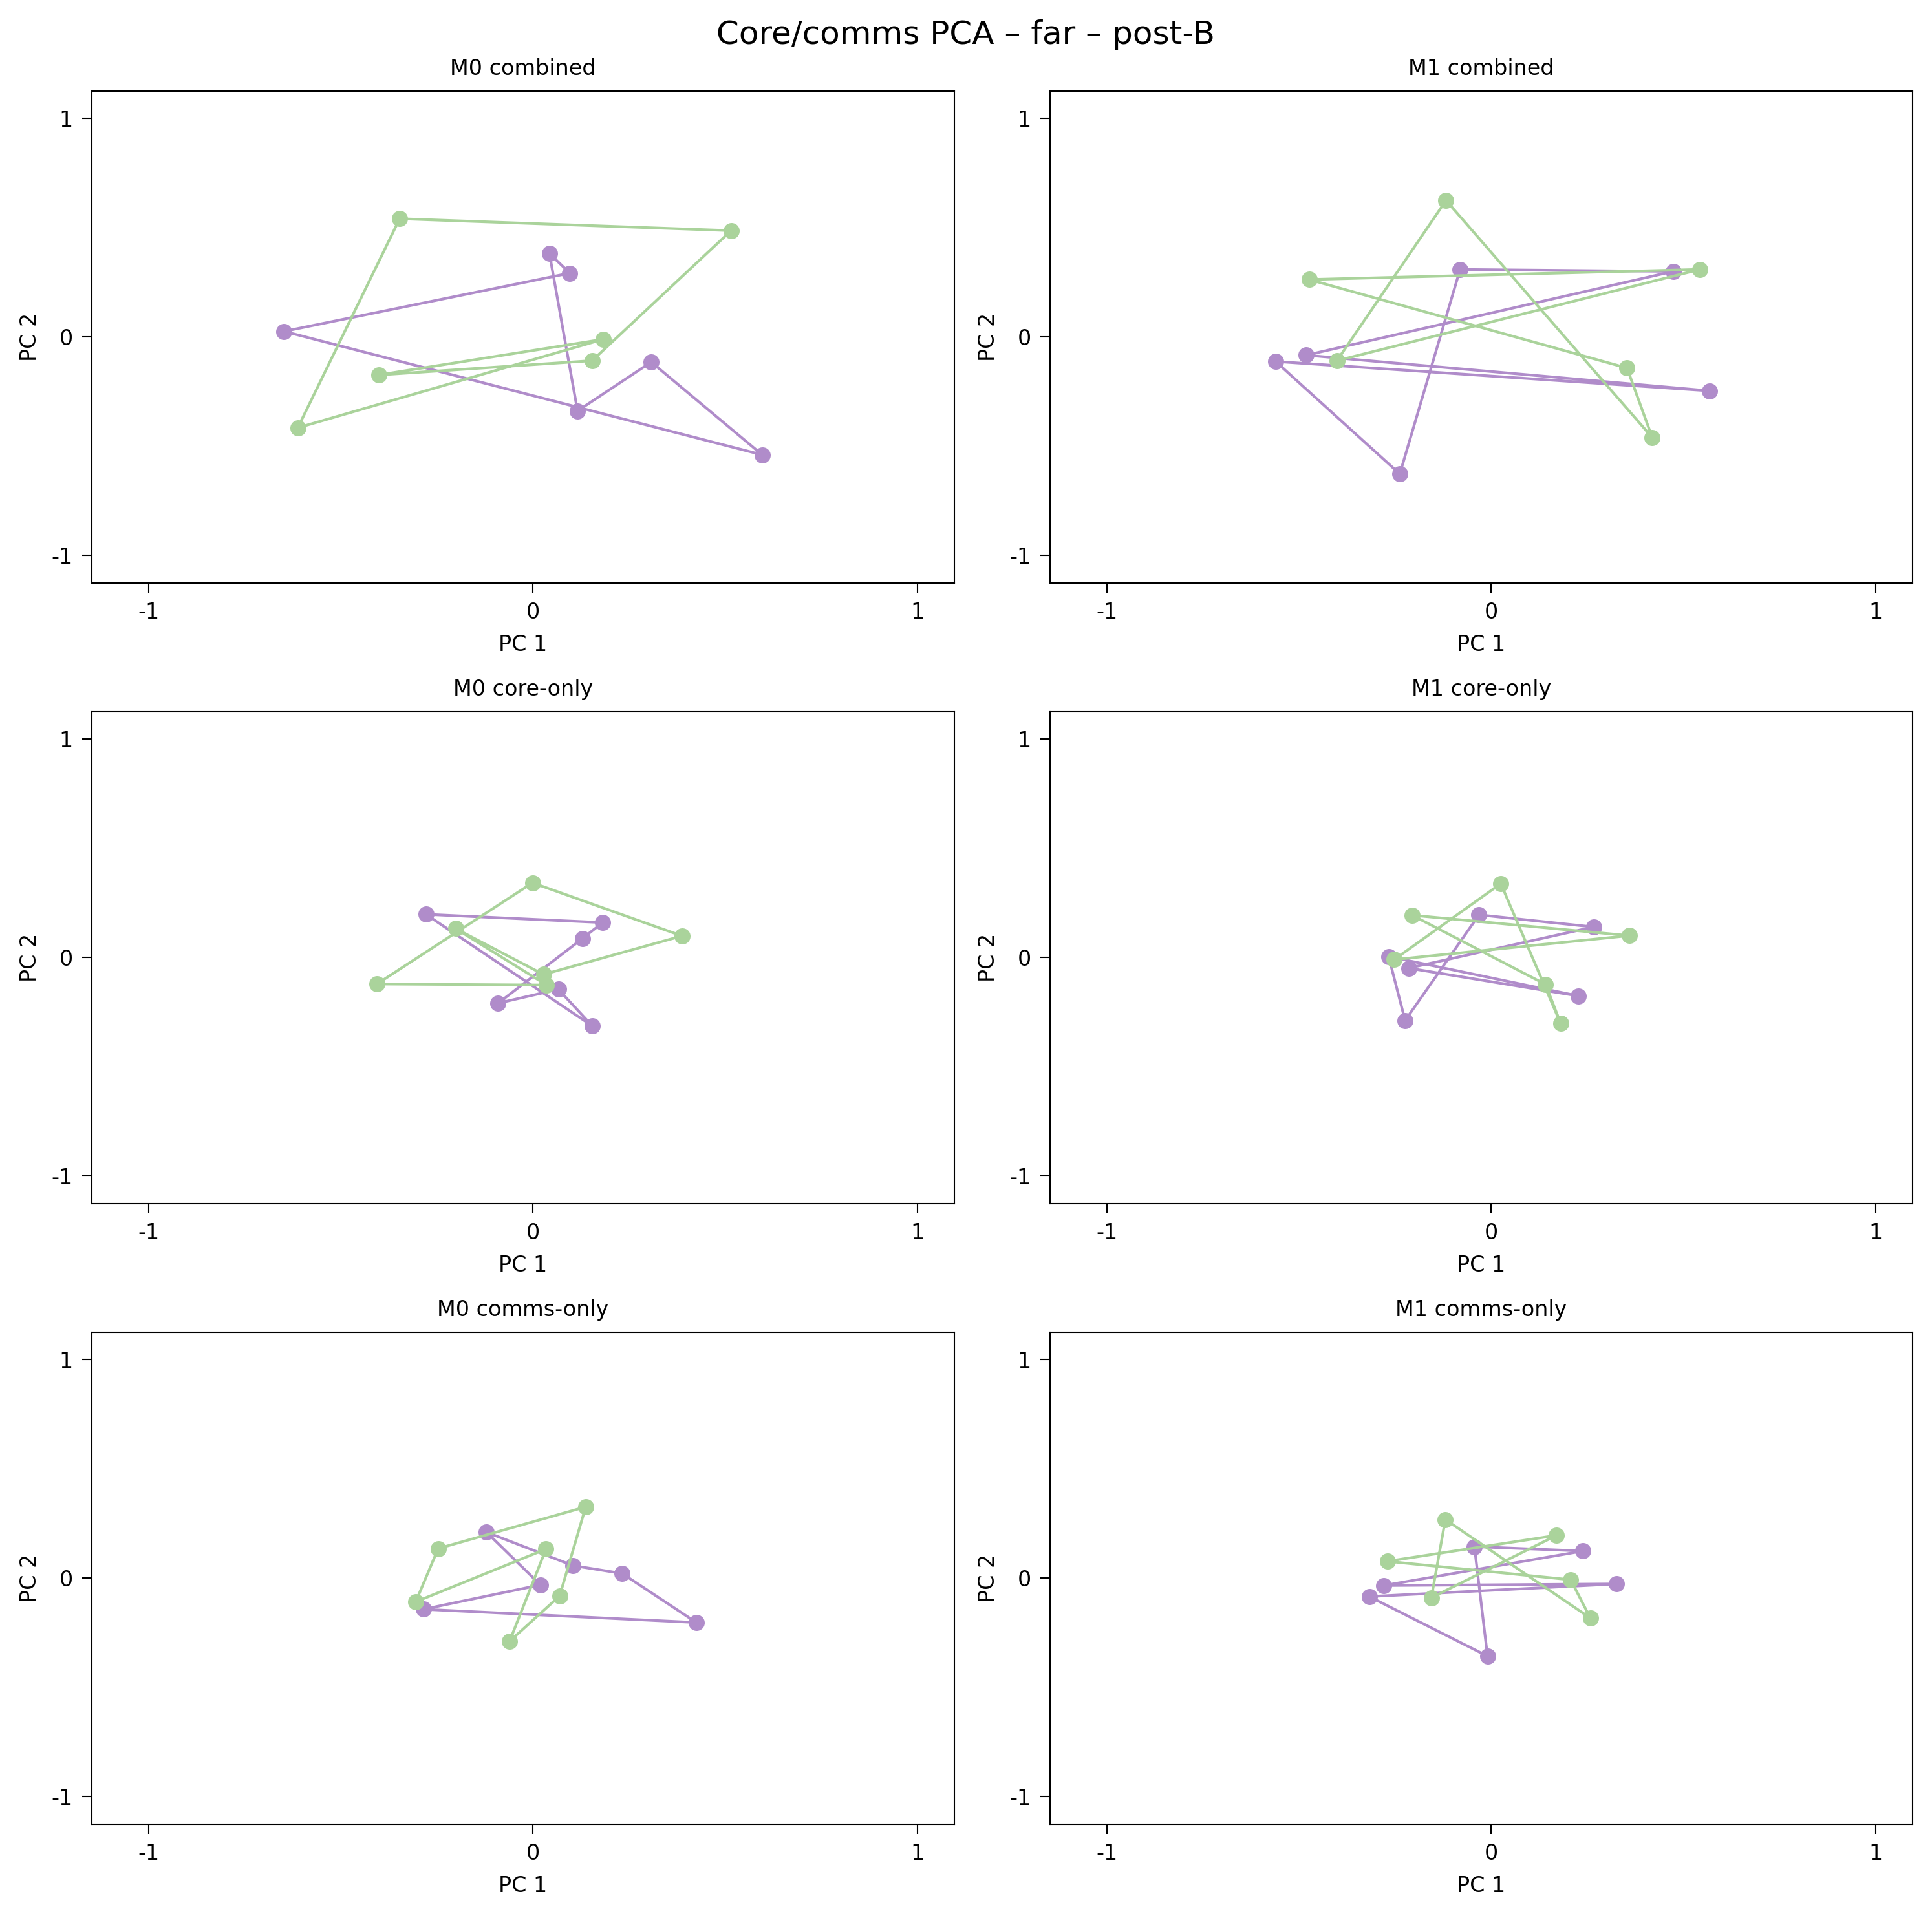

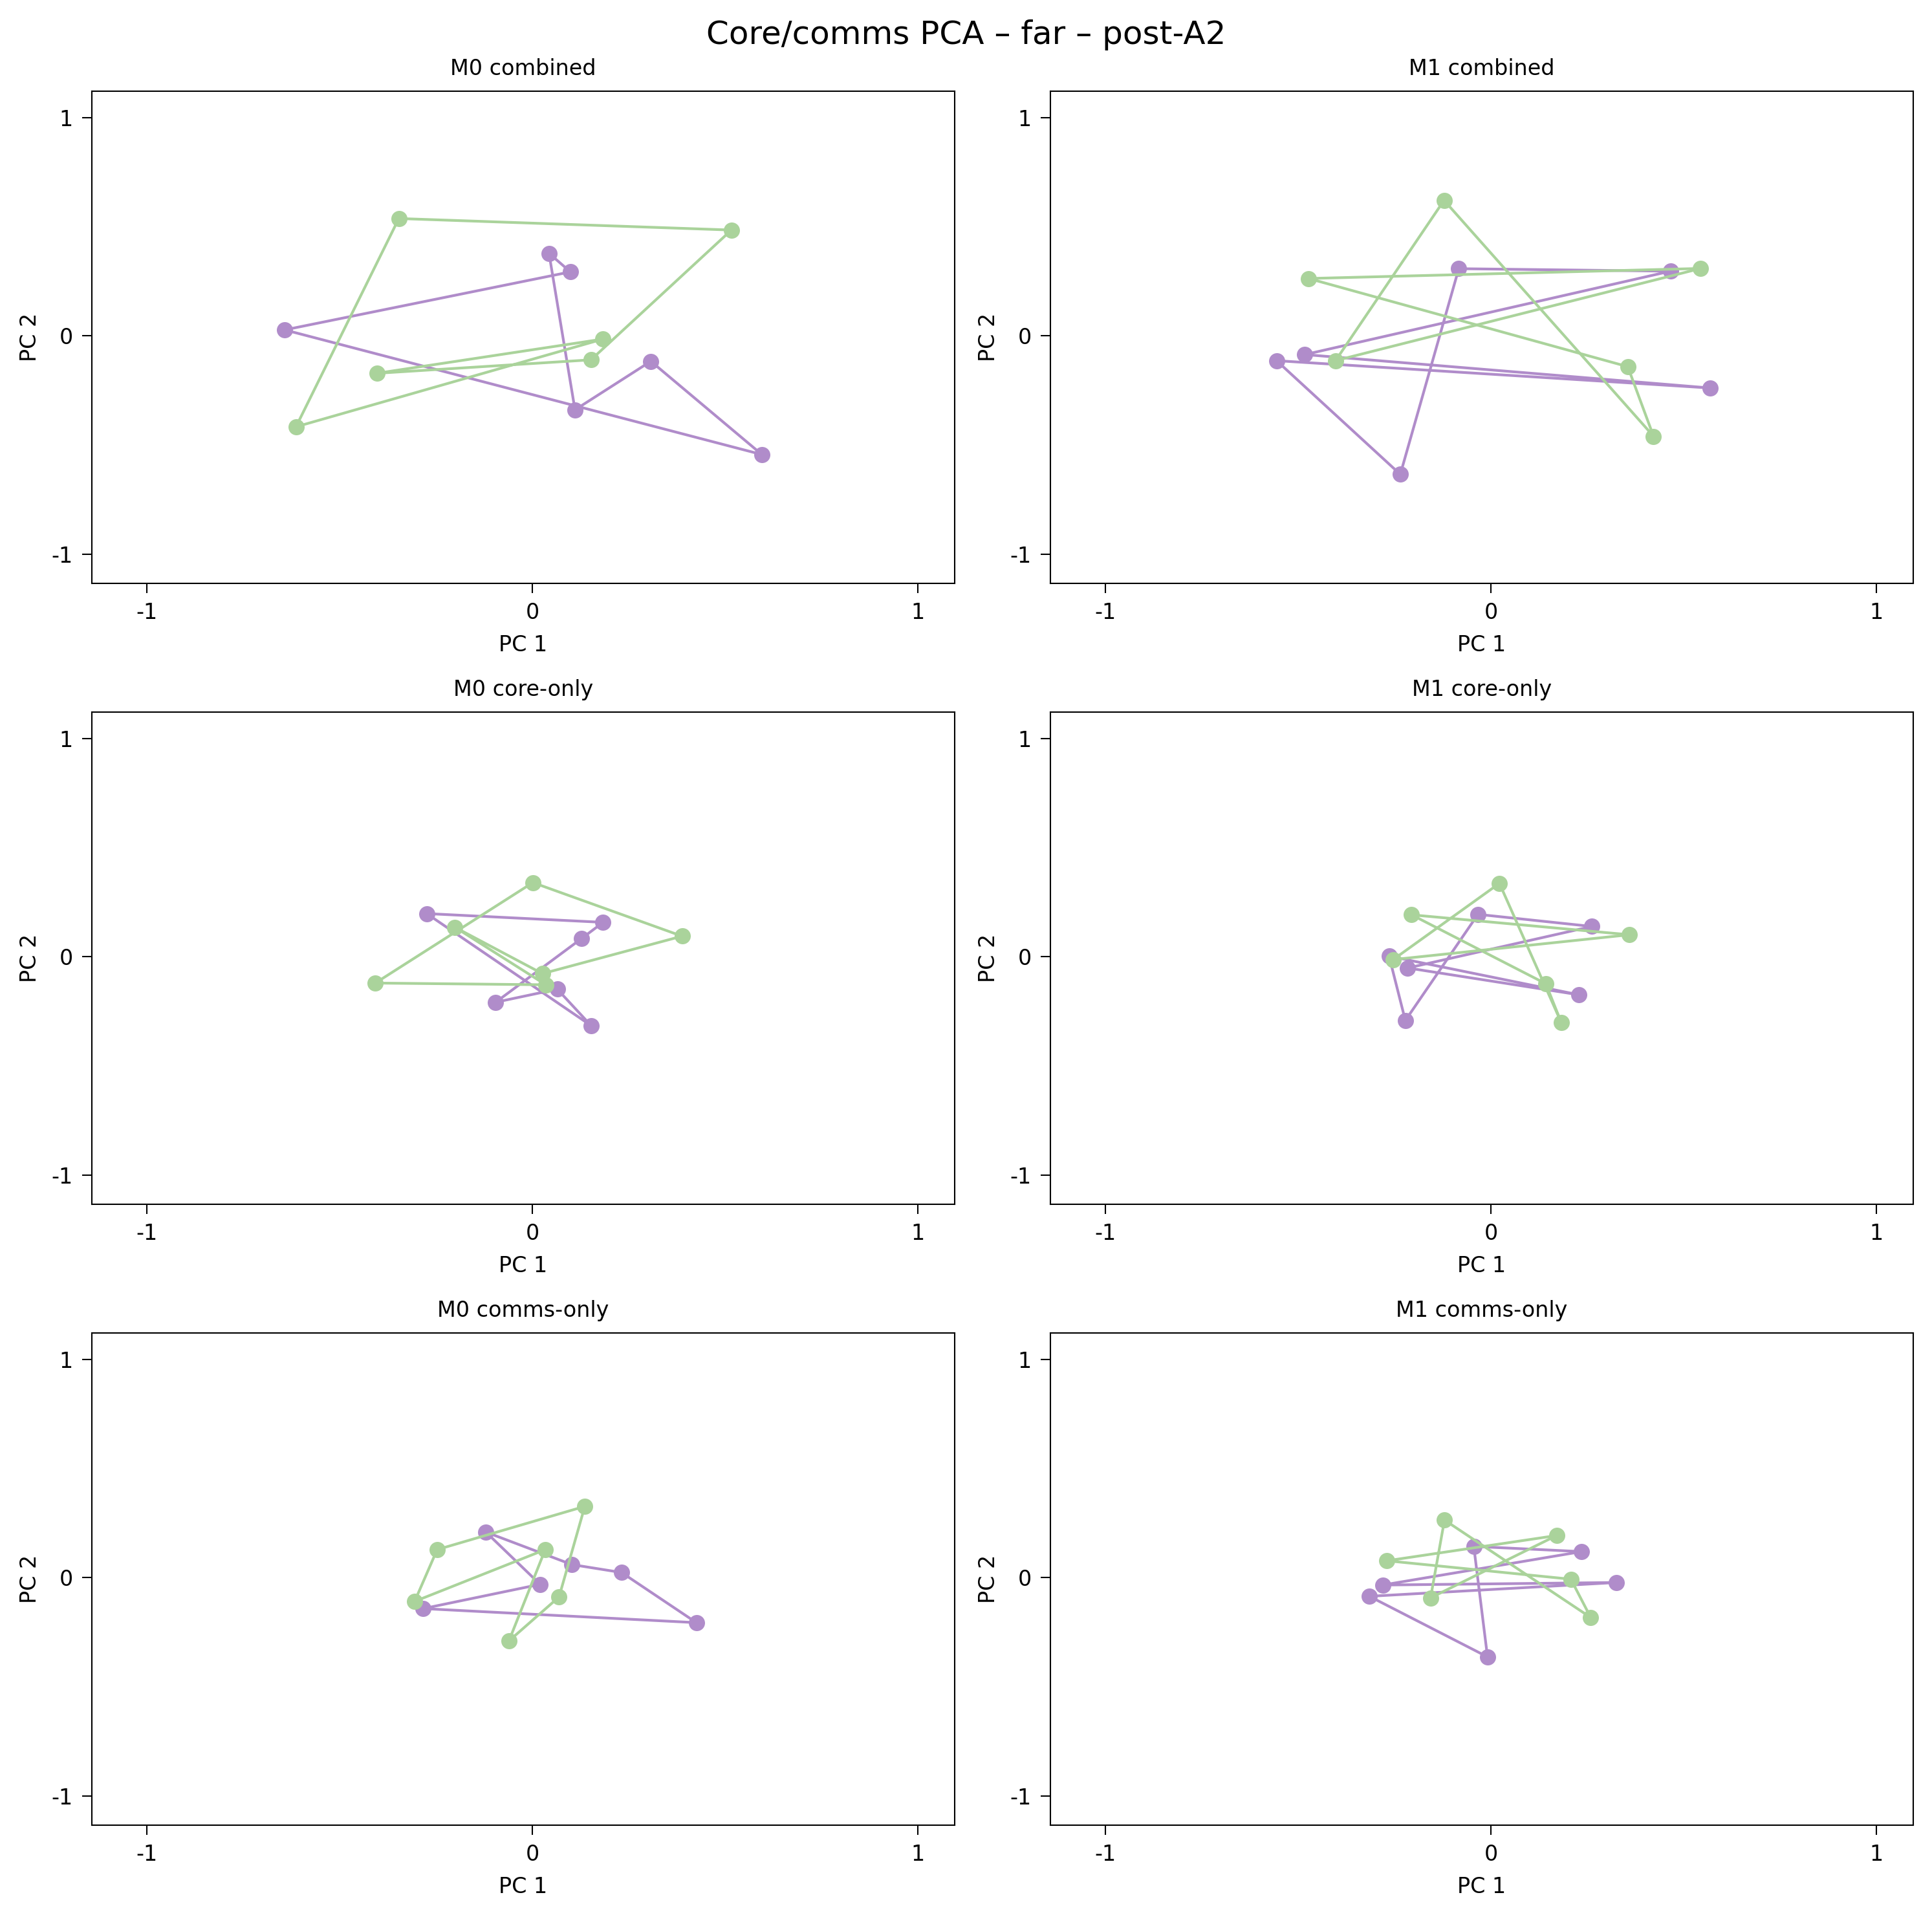

In [6]:
phase_info = [(0, "post-A"), (1, "post-B"), (2, "post-A2")]

for sched_name in schedules:
    if len(ann_data[sched_name]) == 0:
        continue
    entry = ann_data[sched_name][0]

    for phase, phase_label in phase_info:
        h_per = entry.get(f"hiddens_post_phase_{phase}_per_module", None)
        core_per = entry.get(f"hiddens_post_phase_{phase}_core_per_module", None)
        comms_per = entry.get(f"hiddens_post_phase_{phase}_comms_per_module", None)

        if h_per is None:
            print(f"{sched_name} {phase_label}: missing per_module, skipping.")
            continue
        if core_per is None or comms_per is None:
            print(f"{sched_name} {phase_label}: core/comms arrays missing (run with updated schedule to save them), skipping core/comms figures.")
            core_per = None
            comms_per = None

        h12_per = get_hiddens_12_per_module(h_per, sched_name)
        core12 = get_hiddens_12_per_module(core_per, sched_name) if core_per is not None else None
        comms12 = get_hiddens_12_per_module(comms_per, sched_name) if comms_per is not None else None

        m0_comb_2d = pca_2d(h12_per[:, 0, :])
        m1_comb_2d = pca_2d(h12_per[:, 1, :])
        m0_core_2d = pca_2d(core12[:, 0, :]) if core12 is not None else None
        m1_core_2d = pca_2d(core12[:, 1, :]) if core12 is not None else None
        m0_comms_2d = pca_2d(comms12[:, 0, :]) if comms12 is not None else None
        m1_comms_2d = pca_2d(comms12[:, 1, :]) if comms12 is not None else None

        fig, axes = plt.subplots(3, 2, figsize=(10, 10))
        fig.suptitle(f"Core/comms PCA – {sched_name} – {phase_label}", fontsize=12)

        all_2d = [a for a in [m0_comb_2d, m1_comb_2d, m0_core_2d, m1_core_2d, m0_comms_2d, m1_comms_2d] if a is not None]
        lims = get_axis_limits(np.vstack(all_2d)) if all_2d else {}

        plot_geom(axes[0, 0], m0_comb_2d, "M0 combined", task_colours, lims)
        plot_geom(axes[0, 1], m1_comb_2d, "M1 combined", task_colours, lims)
        plot_geom(axes[1, 0], m0_core_2d, "M0 core-only", task_colours, lims)
        plot_geom(axes[1, 1], m1_core_2d, "M1 core-only", task_colours, lims)
        plot_geom(axes[2, 0], m0_comms_2d, "M0 comms-only", task_colours, lims)
        plot_geom(axes[2, 1], m1_comms_2d, "M1 comms-only", task_colours, lims)

        plt.tight_layout()
        plt.show()
